# Step 5: Supervised Learning
## NLP Project 2

**ESILV A4 DIA6 — 2026**

**Authors:** Leo WINTER & Alvaro SERERO


This notebook covers **Step 5**: supervised learning for star rating prediction,
sentiment analysis, and theme classification.

We train and compare several model families:

- **TF-IDF + Logistic Regression**: Classical ML baseline for rating, sentiment, and theme detection
- **Basic trainable embedding model**: Randomly initialised embedding layer trained end-to-end
- **CNN with trained Word2Vec embeddings**: Domain embedding layer (frozen)
- **BiLSTM with trained Word2Vec embeddings**: Recurrent deep learning baseline
- **CNN with pre-trained GloVe embeddings**: Pre-trained embeddings (fine-tuned)
- **BERT**: HuggingFace transformer
- **LLM zero-shot**: No fine-tuning, prompt-based
- **Error analysis + SHAP**: Interpretation
- **Comparison**: All models side-by-side

Two prediction tasks are addressed throughout:
- **5-class rating prediction** (stars 1–5) -> regression / classification
- **3-class sentiment detection** (negative / neutral / positive) -> simpler, more robust

A third supervised task is added for rubric coverage:
- **Theme classification** on `theme_enriched`

**Input:** `reviews_step4.parquet`

**Output:** `reviews_step5.parquet` (adds `pred_lr_rating`, `pred_lr_sentiment`, `pred_theme_lr` columns)


## Table of Contents
1. [Setup & Imports](#setup)
2. [Load Data](#load)
3. [Data Preparation](#prep)
4. [TF-IDF + Logistic Regression](#model1)
5. [Classical Theme Classification](#model1b)
6. [CNN with Trained Word2Vec Embeddings](#model2)
7. [Basic Trainable Embedding Baseline](#model2b)
8. [BiLSTM with Word2Vec Embeddings](#model2c)
9. [CNN with Pre-trained GloVe Embeddings](#model3)
10. [BERT via HuggingFace](#model4)
11. [LLM — Zero-shot Classification](#model5)
12. [Error Analysis & SHAP](#error)
13. [Model Comparison](#comparison)
14. [Save](#save)
15. [Conclusion](#conclusion)


## 0. Dependencies

In [1]:
# %pip install scikit-learn tensorflow transformers shap torch
# %pip install sentencepiece sacremoses

<a id="setup"></a>
## 1. Setup & Imports

In [2]:
import os, sys, re, pickle, datetime, warnings, time
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["USE_TF"] = "0"   # stop transformers trying to import TensorFlow/Keras

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

# Sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.utils.class_weight import compute_class_weight

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Embedding, GlobalAveragePooling1D,
                                      GlobalMaxPooling1D, SpatialDropout1D,
                                      Dense, Dropout, Conv1D, BatchNormalization,
                                      Bidirectional, LSTM)
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorboard.plugins import projector

# Gensim / embeddings
import pickle as pkl
from gensim.models import Word2Vec

# HuggingFace
from transformers import pipeline

# SHAP
import shap

# Device (MPS / CUDA / CPU)
import torch
if torch.backends.mps.is_available():
    DEVICE_HF = "mps";  print("MPS (Apple Silicon) ✓")
elif torch.cuda.is_available():
    DEVICE_HF = "cuda"; print("CUDA GPU ✓")
else:
    DEVICE_HF = "cpu";  print("CPU mode")

DEVICE_TF = "/GPU:0" if tf.config.list_physical_devices("GPU") else "/CPU:0"
print(f"TensorFlow device: {DEVICE_TF}")

CURRENT_DIR = Path.cwd()
if (CURRENT_DIR / "data").exists():
    BASE_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

DATA_PATH   = BASE_DIR / "data"
MODEL_PATH  = BASE_DIR / "model"
VISU_PATH   = BASE_DIR / "visualizations" / "notebook5"
LOG_DIR     = BASE_DIR / "logs" / "step5"
for p in [VISU_PATH, LOG_DIR, MODEL_PATH]:
    p.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MAX_WORDS    = 10_000   # Keras tokenizer vocab size
MAX_LEN      = 100      # max sequence length in tokens
EMBED_DIM    = 100      # embedding dimension (must match W2V / GloVe)
EPOCHS       = 100      # max epochs (early stopping will cut this short)
BATCH_SIZE   = 64


MPS (Apple Silicon) ✓
TensorFlow device: /CPU:0


<a id="load"></a>
## 2. Load Data

In [3]:
df = pd.read_parquet(DATA_PATH / "reviews_step4.parquet")
print(f"Loaded {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")
df[["note", "avis_cor_en", "tokens_en", "theme_enriched"]].head(3)

Loaded 24,092 rows
Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'review_len_words', 'tokens_en', 'tokens_fr', 'avis_summary', 'topic_kmeans_en', 'topic_kmeans_fr', 'topic_lsa_en', 'topic_lsa_fr', 'topic_lda_en', 'topic_lda_fr', 'word_count', 'anomaly_structural', 'anomaly_structural_score', 'anomaly_semantic', 'anomaly_semantic_score', 'theme', 'theme_enriched']


,note,avis_cor_en,tokens_en,theme_enriched
0,5,best insurance price solutions listening speed...,"[good, insurance, price, solution, listen, spe...",Positive Sentiment
1,4,i am generally satisfied except that you have ...,"[generally, satisfied, except, problem, websit...",Claims Handling
2,5,very affordable price several options are avai...,"[affordable, price, several, option, available...",Pricing & Value


In [4]:
# Load saved Word2Vec models from Step 4
class _W2VLoader:
    """Minimal loader — we only need sentence_vec for this notebook."""
    def __init__(self, name):
        self.model = Word2Vec.load(str(MODEL_PATH / f"{name}.model"))
    def __contains__(self, w): return w in self.model.wv
    def vec(self, w):          return self.model.wv[w]
    def vocab_size(self):      return len(self.model.wv.index_to_key)

model_w2v_en = _W2VLoader("word2vec_en")
model_w2v_fr = _W2VLoader("word2vec_fr")
print(f"W2V EN: {model_w2v_en.vocab_size():,} words")
print(f"W2V FR: {model_w2v_fr.vocab_size():,} words")

# Load GloVe model from Step 4
glove_cache = MODEL_PATH / "glove-wiki-gigaword-100.vecs"
with open(glove_cache, "rb") as f:
    glove_kv = pickle.load(f)
print(f"GloVe:  {len(glove_kv.index_to_key):,} words, {glove_kv.vector_size}d")


W2V EN: 7,612 words
W2V FR: 9,025 words
GloVe:  400,000 words, 100d


<a id="prep"></a>
## 3. Data Preparation

### 3.1 Target variables

We define two prediction targets:

- **5-class rating** (`y_rating`): predict stars 1–5 (0–4 after shifting).
  This is the harder task — stars 2/3/4 are semantically close and often confusable.
- **3-class sentiment** (`y_sentiment`): 0=negative (1–2 stars), 1=neutral (3 stars), 2=positive (4–5 stars).
  This is more robust because the boundary between "satisfied" and "very satisfied"
  is clearer in text than the boundary between 2 and 3 stars.

We train models on both tasks and compare performance.


Rating distribution (5-class):
{0: 7266, 1: 3715, 2: 3382, 3: 4883, 4: 4846}

Sentiment distribution (3-class):
{'negative': 10981, 'neutral': 3382, 'positive': 9729}


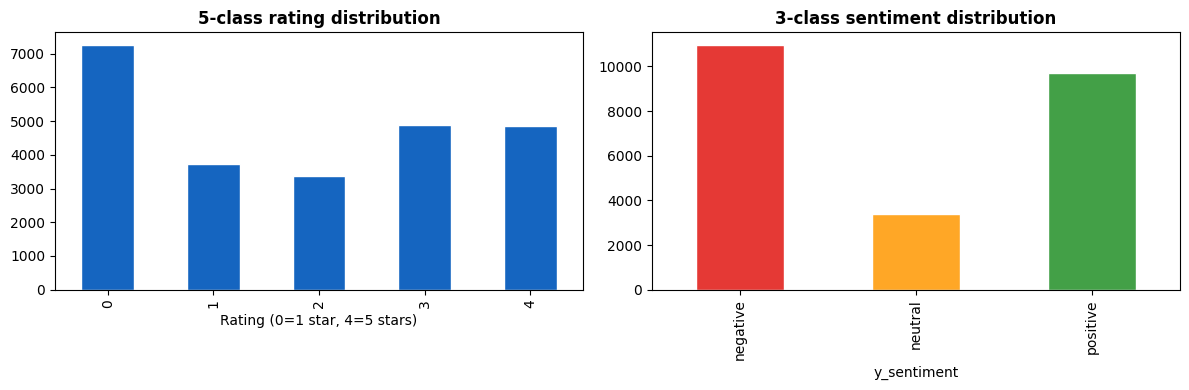

In [5]:
# 5-class rating: shift to 0-indexed for Keras
df["y_rating"] = df["note"] - 1   # 0..4

# 3-class sentiment
def to_sentiment(note):
    if note <= 2: return 0   # negative
    if note == 3: return 1   # neutral
    return 2                  # positive

df["y_sentiment"] = df["note"].apply(to_sentiment)

print("Rating distribution (5-class):")
print(df["y_rating"].value_counts().sort_index().to_dict())
print("\nSentiment distribution (3-class):")
print(df["y_sentiment"].value_counts().sort_index().rename(
    {0: "negative", 1: "neutral", 2: "positive"}).to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["y_rating"].value_counts().sort_index().plot.bar(
    ax=axes[0], color="#1565C0", edgecolor="white")
axes[0].set_title("5-class rating distribution", fontweight="bold")
axes[0].set_xlabel("Rating (0=1 star, 4=5 stars)")

df["y_sentiment"].value_counts().sort_index().rename({0:"negative",1:"neutral",2:"positive"}).plot.bar(
    ax=axes[1], color=["#E53935","#FFA726","#43A047"], edgecolor="white")
axes[1].set_title("3-class sentiment distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "label_distributions.png", bbox_inches="tight")
plt.show()

### 3.2 Train / Validation / Test split

We use a 70/15/15 split stratified by rating. Also, we use a **separate validation
set** for early stopping — not the test set. 


In [6]:
# Stratified 70/15/15 split
def tokenizer_clean(text):
    if isinstance(text, (list, np.ndarray)):
        return " ".join(text)
    if isinstance(text, str):
        words = re.findall(r"[\w']+", text)
        return " ".join(words)
    return ""


X_text_en = df["tokens_en"].apply(tokenizer_clean)
X_text_fr = df["tokens_fr"].apply(tokenizer_clean)
X_raw_en  = df["avis_cor_en"].fillna("").astype(str)  # raw text for BERT/LLM

y_rating    = df["y_rating"]
y_sentiment = df["y_sentiment"]

# First split: 70% train, 30% temp
X_en_tr, X_en_tmp, X_fr_tr, X_fr_tmp, Xr_tr, Xr_tmp, yr_tr,   yr_tmp,   ys_tr,   ys_tmp = train_test_split(
    X_text_en, X_text_fr, X_raw_en,
    y_rating, y_sentiment,
    test_size=0.30, random_state=RANDOM_STATE, stratify=y_rating
)

# Second split: 50/50 of temp → 15% val, 15% test
X_en_val, X_en_test, X_fr_val, X_fr_test, Xr_val, Xr_test, yr_val,   yr_test,   ys_val,   ys_test = train_test_split(
    X_en_tmp, X_fr_tmp, Xr_tmp,
    yr_tmp, ys_tmp,
    test_size=0.50, random_state=RANDOM_STATE, stratify=yr_tmp
)

print(f"Train: {len(X_en_tr):,}  |  Val: {len(X_en_val):,}  |  Test: {len(X_en_test):,}")
print(f"Rating class distribution in test: {yr_test.value_counts().sort_index().to_dict()}")

# Class weights for imbalanced dataset
cw_rating = compute_class_weight("balanced",
                                  classes=np.arange(5), y=yr_tr.values)
cw_sentiment = compute_class_weight("balanced",
                                     classes=np.arange(3), y=ys_tr.values)
cw_dict_rating    = dict(enumerate(cw_rating))
cw_dict_sentiment = dict(enumerate(cw_sentiment))
print(f"\nClass weights (rating):    {cw_dict_rating}")
print(f"Class weights (sentiment): {cw_dict_sentiment}")

Train: 16,864  |  Val: 3,614  |  Test: 3,614
Rating class distribution in test: {0: 1090, 1: 557, 2: 508, 3: 732, 4: 727}

Class weights (rating):    {0: np.float64(0.6631537554069996), 1: np.float64(1.296732026143791), 2: np.float64(1.4249260667511618), 3: np.float64(0.9867758923346986), 4: np.float64(0.9943396226415094)}
Class weights (sentiment): {0: np.float64(0.7312779150947487), 1: np.float64(2.374876777918603), 2: np.float64(0.8254527655408712)}


In [7]:
# Keras sequence preparation (used in models 2 and 3)
tok_en = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>", filters="", lower=False)
tok_en.fit_on_texts(X_en_tr.tolist())

tok_fr = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>", filters="", lower=False)
tok_fr.fit_on_texts(X_fr_tr.tolist())

def to_padded(tokenizer, texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post")

# Rating task
Xp_en_tr   = to_padded(tok_en, X_en_tr);   Xp_en_val = to_padded(tok_en, X_en_val)
Xp_en_test = to_padded(tok_en, X_en_test)
Xp_fr_tr   = to_padded(tok_fr, X_fr_tr);   Xp_fr_val = to_padded(tok_fr, X_fr_val)
Xp_fr_test = to_padded(tok_fr, X_fr_test)

print(f"Padded EN train: {Xp_en_tr.shape}  |  test: {Xp_en_test.shape}")

# Embedding matrices
def make_embedding_matrix(tokenizer, wv_obj, dim=EMBED_DIM):
    """Map tokenizer indices to pre-trained vectors (zeros for unknown words)."""
    vocab_size = min(len(tokenizer.word_index) + 1, MAX_WORDS + 1)
    mat = np.zeros((vocab_size, dim))
    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size: continue
        try:
            vec = wv_obj[word] if hasattr(wv_obj, "__getitem__") else None
            if vec is not None: mat[idx] = vec
        except KeyError:
            pass
    return mat

emb_w2v_en = make_embedding_matrix(tok_en, model_w2v_en.model.wv)
emb_w2v_fr = make_embedding_matrix(tok_fr, model_w2v_fr.model.wv)
emb_glove   = make_embedding_matrix(tok_en, glove_kv)

print(f"W2V EN matrix:  {emb_w2v_en.shape}")
print(f"GloVe matrix:   {emb_glove.shape}")


Padded EN train: (16864, 100)  |  test: (3614, 100)
W2V EN matrix:  (10001, 100)
GloVe matrix:   (10001, 100)


### 3.3 Shared evaluation helpers

In [8]:
results_store = {}   # accumulate all model results for the comparison table

def evaluate_model(name, y_true, y_pred, n_classes=None, task="rating", display_labels=None):
    """Print classification report, plot confusion matrix, store results."""
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")

    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print(classification_report(y_true, y_pred, zero_division=0))

    if display_labels is not None:
        labels = list(display_labels)
    elif n_classes == 5:
        labels = ["1★", "2★", "3★", "4★", "5★"]
    elif n_classes == 3:
        labels = ["Negative", "Neutral", "Positive"]
    else:
        labels = sorted(pd.Series(y_true).astype(str).unique().tolist())

    fig, ax = plt.subplots(figsize=(7, max(5, len(labels) * 0.6)))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=labels, ax=ax,
        colorbar=False, cmap="Blues"
    )
    ax.set_title(f"Confusion Matrix — {name}", fontweight="bold")
    plt.tight_layout()
    fname = name.replace(" ", "_").replace("/", "_")
    plt.savefig(VISU_PATH / f"cm_{fname}.png", bbox_inches="tight")
    plt.show()

    results_store[name] = {
        "task": task, "accuracy": round(acc, 4), "macro_f1": round(f1, 4)
    }
    return acc, f1


def plot_history(history, name):
    """Plot training and validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, title in [
        (axes[0], "accuracy", "Accuracy"),
        (axes[1], "loss",     "Loss"),
    ]:
        ax.plot(history.history[metric],         label="Train", linewidth=1.5)
        ax.plot(history.history[f"val_{metric}"], label="Val",   linewidth=1.5)
        ax.set_title(f"{title} — {name}", fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    fname = name.replace(" ", "_").replace("/", "_")
    plt.savefig(VISU_PATH / f"history_{fname}.png", bbox_inches="tight")
    plt.show()


def show_error_cases(name, X_raw, y_true, y_pred, n=5):
    """Display the n reviews where the model was most confidently wrong."""
    wrong_mask = np.array(y_true) != np.array(y_pred)
    wrong_idx  = np.where(wrong_mask)[0]
    if len(wrong_idx) == 0:
        print("No errors found.")
        return

    sample = wrong_idx[:n]
    print(f"\nError analysis — {name} (first {n} wrong predictions):")
    print(f"{'─'*80}")
    for i in sample:
        true_val = y_true.iloc[i] if hasattr(y_true, 'iloc') else y_true[i]
        print(f"  True: {true_val}  Pred: {y_pred[i]}")
        text = str(X_raw.iloc[i] if hasattr(X_raw, 'iloc') else X_raw[i])
        print(f"  Review: {text[:200]}")
        print()


def es(patience=7):
    return EarlyStopping(monitor="val_loss", patience=patience,
                         restore_best_weights=True, verbose=0)


def tb_callback(name):
    ts  = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    path = str(LOG_DIR / name / ts)
    return TensorBoard(log_dir=path, histogram_freq=1, embeddings_freq=1)


<a id="model1"></a>
## 4. TF-IDF + Logistic Regression

The TF-IDF + Logistic Regression pipeline is our **classical ML baseline**.     
We train it on two tasks (5-class rating, 3-class sentiment) and for both languages.
`class_weight='balanced'` compensates for the rating imbalance automatically.


In [9]:
def train_tfidf_lr(X_train, X_val, X_test, y_train, y_val, y_test,
                   label, task, n_classes, display_labels=None):
    """Fit TF-IDF + LogisticRegression and evaluate on test set."""
    tfidf = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, max_features=20_000)
    Xtr = tfidf.fit_transform(X_train)
    Xvl = tfidf.transform(X_val)
    Xts = tfidf.transform(X_test)

    # Concatenate train+val for final fit (best practice after hyperparam selection)
    import scipy.sparse
    Xtr_full = scipy.sparse.vstack([Xtr, Xvl])
    ytr_full = pd.concat([y_train, y_val])

    lr = LogisticRegression(max_iter=1000, class_weight="balanced",
                             C=1.0, solver="saga", random_state=RANDOM_STATE)
    lr.fit(Xtr_full, ytr_full)

    y_pred = lr.predict(Xts)
    evaluate_model(
        label,
        y_test,
        y_pred,
        n_classes=n_classes,
        task=task,
        display_labels=display_labels,
    )
    return tfidf, lr, y_pred


5-class Rating Prediction

────────────────────────────────────────────────────────────
  TF-IDF + LR (EN, 5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.67      0.65      0.66      1090
           1       0.36      0.40      0.38       557
           2       0.32      0.32      0.32       508
           3       0.45      0.41      0.43       732
           4       0.55      0.56      0.55       727

    accuracy                           0.50      3614
   macro avg       0.47      0.47      0.47      3614
weighted avg       0.50      0.50      0.50      3614



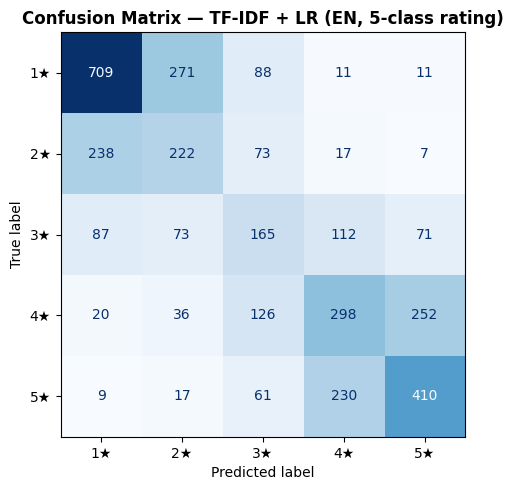


────────────────────────────────────────────────────────────
  TF-IDF + LR (FR, 5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.68      0.67      0.68      1090
           1       0.35      0.40      0.37       557
           2       0.31      0.31      0.31       508
           3       0.44      0.38      0.41       732
           4       0.56      0.58      0.57       727

    accuracy                           0.50      3614
   macro avg       0.47      0.47      0.47      3614
weighted avg       0.50      0.50      0.50      3614



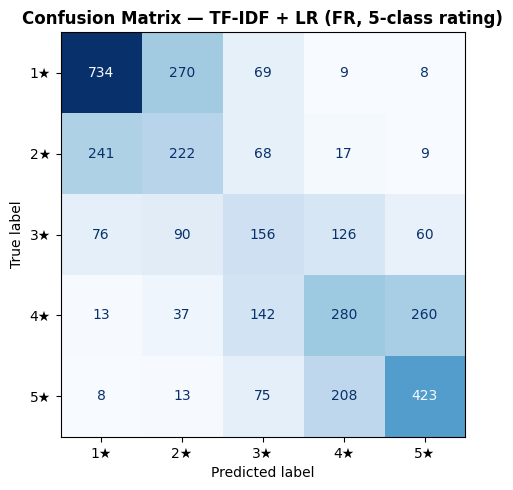

In [10]:
# 5-class rating task
print("5-class Rating Prediction")
tfidf_en, lr_rating_en, pred_lr_en = train_tfidf_lr(
    X_en_tr, X_en_val, X_en_test,
    yr_tr, yr_val, yr_test,
    "TF-IDF + LR (EN, 5-class rating)", "rating", 5
)
tfidf_fr, lr_rating_fr, pred_lr_fr = train_tfidf_lr(
    X_fr_tr, X_fr_val, X_fr_test,
    yr_tr, yr_val, yr_test,
    "TF-IDF + LR (FR, 5-class rating)", "rating", 5
)


3-class Sentiment Detection

────────────────────────────────────────────────────────────
  TF-IDF + LR (EN, sentiment)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1647
           1       0.30      0.36      0.33       508
           2       0.84      0.79      0.82      1459

    accuracy                           0.76      3614
   macro avg       0.67      0.67      0.67      3614
weighted avg       0.77      0.76      0.77      3614



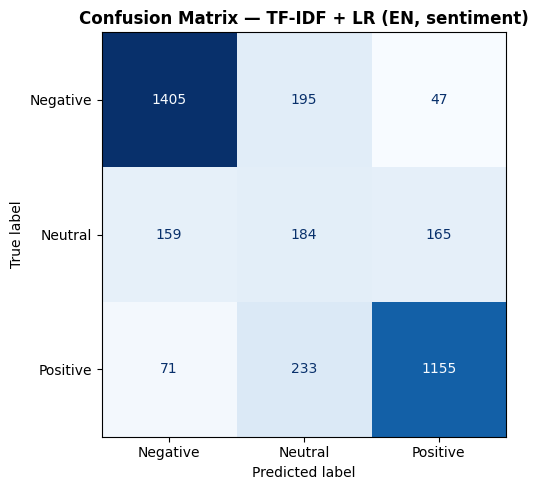


────────────────────────────────────────────────────────────
  TF-IDF + LR (FR, sentiment)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      1647
           1       0.28      0.35      0.31       508
           2       0.84      0.78      0.81      1459

    accuracy                           0.76      3614
   macro avg       0.67      0.67      0.67      3614
weighted avg       0.78      0.76      0.77      3614



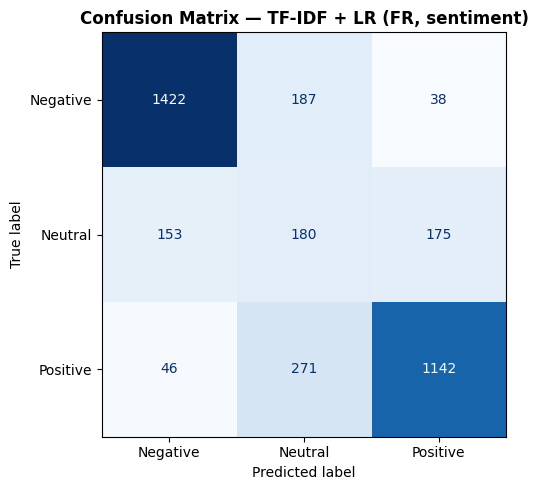

In [11]:
# 3-class sentiment task
print("3-class Sentiment Detection")
_, lr_sent_en, pred_sent_en = train_tfidf_lr(
    X_en_tr, X_en_val, X_en_test,
    ys_tr, ys_val, ys_test,
    "TF-IDF + LR (EN, sentiment)", "sentiment", 3
)
_, lr_sent_fr, pred_sent_fr = train_tfidf_lr(
    X_fr_tr, X_fr_val, X_fr_test,
    ys_tr, ys_val, ys_test,
    "TF-IDF + LR (FR, sentiment)", "sentiment", 3
)

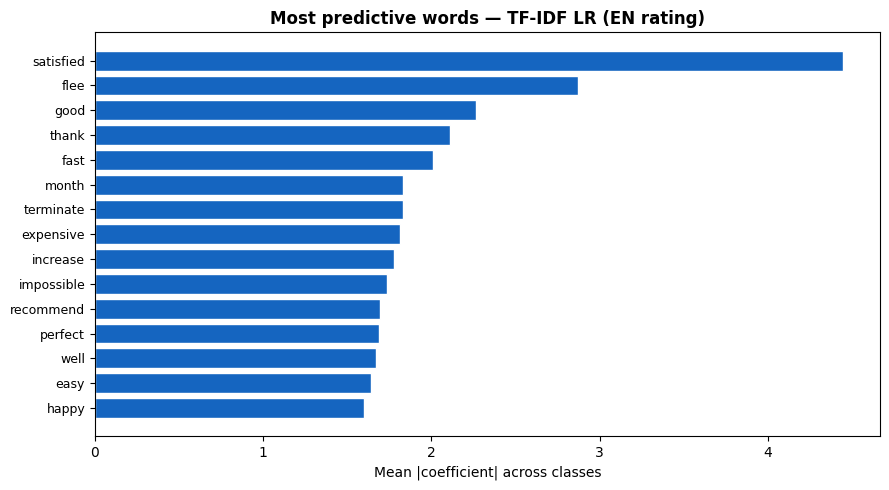

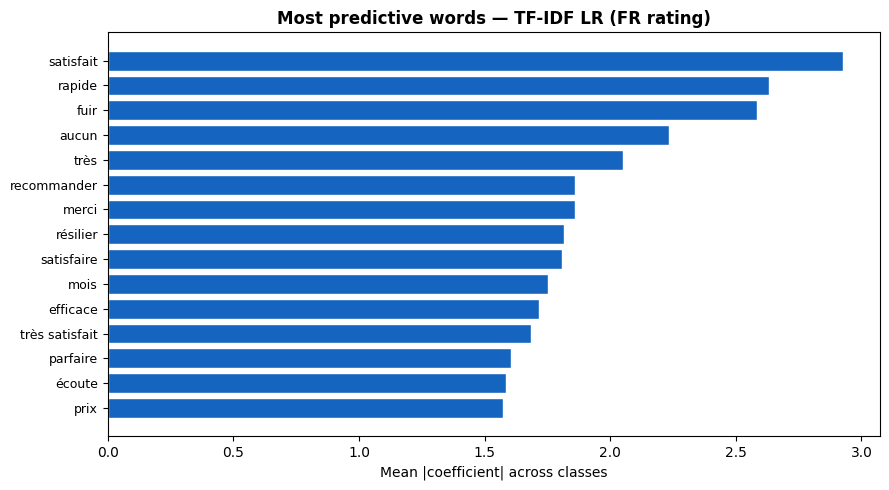

In [12]:
# Most informative words per class
# We show the mean absolute coefficient across all classes — words that
# are strong predictors for ANY rating level (not just the first class).
def plot_top_features(tfidf, lr_model, title, top_n=15, fname=None):
    feature_names = tfidf.get_feature_names_out()
    # mean |coefficient| across all classes → overall word importance
    importance = np.abs(lr_model.coef_).mean(axis=0)
    top_idx    = importance.argsort()[-top_n:][::-1]
    top_words  = [feature_names[i] for i in top_idx]
    top_scores = [importance[i]    for i in top_idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(range(top_n), top_scores[::-1], color="#1565C0", edgecolor="white")
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_words[::-1], fontsize=9)
    ax.set_xlabel("Mean |coefficient| across classes")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    if fname: plt.savefig(VISU_PATH / f"{fname}.png", bbox_inches="tight")
    plt.show()

plot_top_features(tfidf_en, lr_rating_en,
                  "Most predictive words — TF-IDF LR (EN rating)",
                  fname="lr_top_features_en")
plot_top_features(tfidf_fr, lr_rating_fr,
                  "Most predictive words — TF-IDF LR (FR rating)",
                  fname="lr_top_features_fr")


In [13]:
# Per-class top words
# For each star rating, show the words most strongly associated with it
def top_words_per_class(tfidf, lr_model, class_labels, top_n=8):
    feature_names = tfidf.get_feature_names_out()
    print("Most predictive words per class:")
    for i, label in enumerate(class_labels):
        if i >= len(lr_model.coef_): break
        top_idx = lr_model.coef_[i].argsort()[-top_n:][::-1]
        words   = [feature_names[j] for j in top_idx]
        print(f"  {label}: {', '.join(words)}")

top_words_per_class(tfidf_en, lr_rating_en,
                    ["1 star","2 stars","3 stars","4 stars","5 stars"])
print()
top_words_per_class(tfidf_en, lr_sent_en,
                    ["Negative","Neutral","Positive"])


Most predictive words per class:
  1 star: flee, avoid, increase, month, incompetent, terminate, pay, expensive
  2 stars: terminate, refuse, impossible, flee, still, month, email, deplorable
  3 stars: genial, high, therefore, little, badge, however, opinion, meet
  4 stars: satisfied, good, fast, well, never problem, easy, clear, downside
  5 stars: satisfied, thank, recommend, perfect, top, fast, happy, good

Most predictive words per class:
  Negative: flee, terminate, avoid, incompetent, month, impossible, increase, call
  Neutral: genial, high, therefore, badge, insurance send, little, useful, policy
  Positive: satisfied, good, perfect, fast, thank, top, happy, recommend


In [14]:
# Error analysis
show_error_cases("TF-IDF LR EN (rating)",
                 Xr_test.reset_index(drop=True),
                 yr_test.reset_index(drop=True), pred_lr_en)



Error analysis — TF-IDF LR EN (rating) (first 5 wrong predictions):
────────────────────────────────────────────────────────────────────────────────
  True: 2  Pred: 0
  Review: hello i am exasperated by the slowness of processing my work stoppage file outside mission i have stopped since 3 07 2019 send the documents since july by post and electronic means i do not stop calli

  True: 1  Pred: 0
  Review: like many people i am scandalized by this practice which consists in terminating a driver after a single accident i was caught in a pileup due to a boar a few cars further small accident but long move

  True: 0  Pred: 1
  Review: disappointed before making sure i like any other insurance i sent my information statement of the vehicle concerned and i find myself terminating for a disaster break of ice due to the blow that dates

  True: 1  Pred: 2
  Review: insurance where employees walk you without finding a solution erroneous green card date however payment is requested immediately

<a id="model1b"></a>
## 4B. Classical Theme Classification

We train a second **TF-IDF + Logistic Regression** baseline, but now on the
`theme_enriched` labels created in Step 4. This directly covers the rubric item
for **classical models with themes** and gives us a fast local subject classifier
for the Streamlit prediction page.

Theme distribution (full dataset):
theme_enriched
Customer Service       7106
Pricing & Value        5826
Positive Sentiment     4159
Claims Handling        3250
Contract Management    1573
Health Coverage        1186
Other                   992


────────────────────────────────────────────────────────────
  TF-IDF + LR (EN, theme)
────────────────────────────────────────────────────────────
                     precision    recall  f1-score   support

    Claims Handling       0.83      0.88      0.85       488
Contract Management       0.65      0.88      0.75       236
   Customer Service       0.93      0.84      0.88      1066
    Health Coverage       0.83      0.89      0.86       178
              Other       0.65      0.96      0.78       148
 Positive Sentiment       0.88      0.89      0.88       624
    Pricing & Value       0.91      0.81      0.86       874

           accuracy                           0.85      3614
          macro avg       0.81      0.88      0.84   

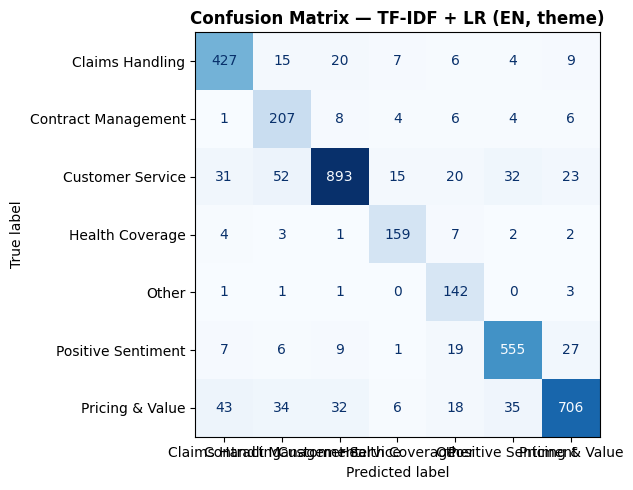

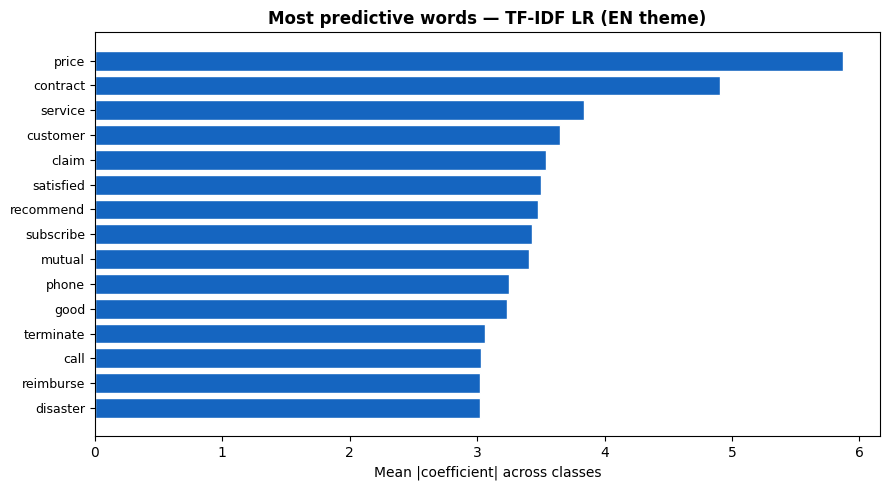


Most predictive words per class:
  Claims Handling: claim, disaster, reimbursement, accident, reimburse, damage, refund, sinister
  Contract Management: contract, subscribe, terminate, termination, notice, period, terminate contract, cancel
  Customer Service: service, customer, phone, call, answer, email, contact, wait
  Health Coverage: mutual, care, health, load, medical, charge, doctor, dental
  Other: flee, badge, opinion, clear explanation, take insurance, prefer, bank, member
  Positive Sentiment: satisfied, recommend, good, fast, effective, practical, happy, quick
  Pricing & Value: price, expensive, increase, cost, contribution, high, cheap, reasonable


Error analysis — TF-IDF LR EN (theme) (first 5 wrong predictions):
────────────────────────────────────────────────────────────────────────────────
  True: Customer Service  Pred: Contract Management
  Review: i do not recommend this mutual insurance i don t want to repeat the same thing that you know better than me i beg you

In [15]:
# Theme classification split (fresh 70/15/15, stratified on theme labels)
y_theme = df["theme_enriched"].astype(str)
theme_labels = sorted(y_theme.unique().tolist())

Xt_theme_tr, Xt_theme_tmp, Xr_theme_tr, Xr_theme_tmp, yt_theme_tr, yt_theme_tmp = train_test_split(
    X_text_en, X_raw_en,
    y_theme,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_theme,
)

Xt_theme_val, Xt_theme_test, Xr_theme_val, Xr_theme_test, yt_theme_val, yt_theme_test = train_test_split(
    Xt_theme_tmp, Xr_theme_tmp,
    yt_theme_tmp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=yt_theme_tmp,
)

print("Theme distribution (full dataset):")
print(y_theme.value_counts().to_string())
print()

tfidf_theme_en, lr_theme_en, pred_theme_en = train_tfidf_lr(
    Xt_theme_tr, Xt_theme_val, Xt_theme_test,
    yt_theme_tr, yt_theme_val, yt_theme_test,
    label="TF-IDF + LR (EN, theme)",
    task="theme",
    n_classes=len(theme_labels),
    display_labels=theme_labels,
)

plot_top_features(
    tfidf_theme_en,
    lr_theme_en,
    "Most predictive words — TF-IDF LR (EN theme)",
    fname="lr_top_features_theme_en",
)
print()
top_words_per_class(tfidf_theme_en, lr_theme_en, theme_labels)
print()
show_error_cases(
    "TF-IDF LR EN (theme)",
    Xr_theme_test.reset_index(drop=True),
    yt_theme_test.reset_index(drop=True),
    pred_theme_en,
)


<a id="model2"></a>
## 5. CNN with Trained Word2Vec Embeddings

We use a 1D Convolutional Neural Network with an Embedding layer initialised from
our custom **Word2Vec** weights and kept **frozen** (`trainable=False`).

**Architecture:** Embedding → SpatialDropout → Conv1D → GlobalMaxPool → Dense → Output

The same architecture is used for both EN and FR tasks, with different embedding matrices.


In [16]:
def build_cnn(embedding_matrix, n_classes, dropout=0.3, trainable=False,
              lr=5e-4, conv_filters=128, conv_kernel=5):
    """
    Generic 1D-CNN for text classification.
    embedding_matrix : pre-computed embedding weights (vocab_size × embed_dim)
    n_classes        : 5 for rating, 3 for sentiment
    trainable        : False = frozen embeddings, True = fine-tuned
    """
    vocab_size, embed_dim = embedding_matrix.shape
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(vocab_size, embed_dim, weights=[embedding_matrix],
                  trainable=trainable),
        SpatialDropout1D(0.5),
        Conv1D(conv_filters, conv_kernel, activation="relu", padding="same"),
        GlobalMaxPooling1D(),
        BatchNormalization(),
        Dense(64, activation="relu",
              kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(dropout),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=["accuracy"]
    )
    return model

Training CNN + W2V EN (rating)…


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 100)       │     1,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 100, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,073,321 (4.09 MB)

 Trainable params: 72,965 (285.02 KB)

 Non-trainable params: 1,000,356 (3.82 MB)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4093 - loss: 1.4189 - val_accuracy: 0.4776 - val_loss: 1.2441
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4466 - loss: 1.2784 - val_accuracy: 0.5028 - val_loss: 1.1642
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4635 - loss: 1.2235 - val_accuracy: 0.4994 - val_loss: 1.1386
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4821 - loss: 1.1941 - val_accuracy: 0.5091 - val_loss: 1.1340
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4908 - loss: 1.1717 - val_accuracy: 0.5102 - val_loss: 1.1212
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4941 - loss: 1.1604 - val_accuracy: 0.5077 - val_loss: 1.1227
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5008 - loss: 1.1477 - val_accuracy: 0.5058 - val_loss: 1.1211
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5018 - loss: 1.1365 - val_accu

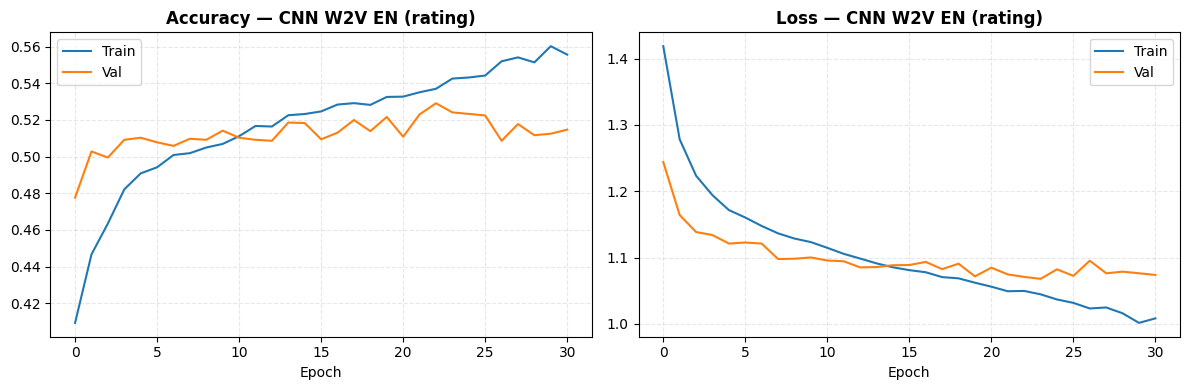

In [17]:
# Train CNN EN (5-class rating)
print("Training CNN + W2V EN (rating)…")
cnn_w2v_en = build_cnn(emb_w2v_en, n_classes=5)
cnn_w2v_en.summary()

history_w2v_en = cnn_w2v_en.fit(
    Xp_en_tr, yr_tr,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(Xp_en_val, yr_val),
    callbacks=[es(patience=7), tb_callback("cnn_w2v_en")],
    verbose=1
)
plot_history(history_w2v_en, "CNN W2V EN (rating)")

Training CNN + W2V FR (rating)…
Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3441 - loss: 1.5400 - val_accuracy: 0.4256 - val_loss: 1.2876
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3935 - loss: 1.3504 - val_accuracy: 0.4400 - val_loss: 1.2174
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4189 - loss: 1.2847 - val_accuracy: 0.4496 - val_loss: 1.1856
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4330 - loss: 1.2585 - val_accuracy: 0.4480 - val_loss: 1.1872
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4326 - loss: 1.2379 - val_accuracy: 0.4488 - val_loss: 1.1911
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4491 - loss: 1.2180 - val_accuracy: 0.4640 - val_loss: 1.1676
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4628 - loss: 1.2059 - val_accuracy: 0.4723 - val_loss: 1.1655
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accurac

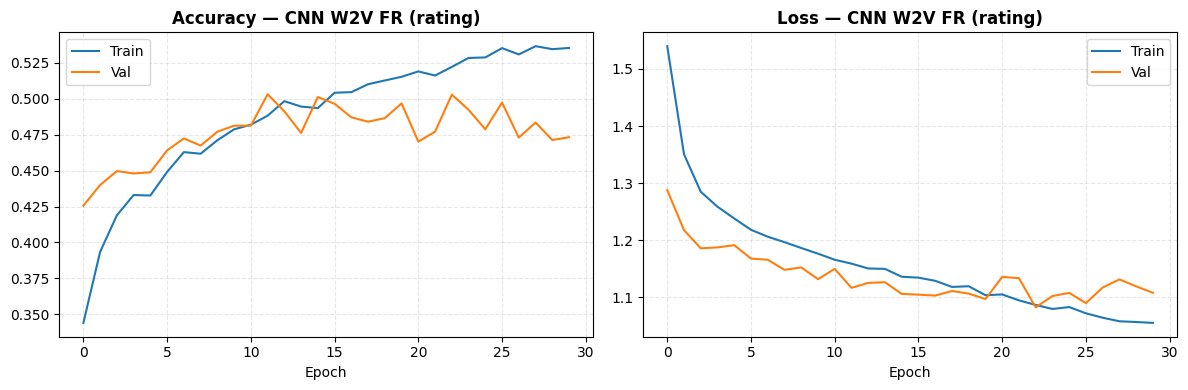

In [18]:
# Train CNN FR (5-class rating)
print("Training CNN + W2V FR (rating)…")
cnn_w2v_fr = build_cnn(emb_w2v_fr, n_classes=5)

history_w2v_fr = cnn_w2v_fr.fit(
    Xp_fr_tr, yr_tr,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(Xp_fr_val, yr_val),
    class_weight=cw_dict_rating,
    callbacks=[es(patience=7), tb_callback("cnn_w2v_fr")],
    verbose=1
)
plot_history(history_w2v_fr, "CNN W2V FR (rating)")

Training CNN + W2V EN (sentiment)…
Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5939 - loss: 0.9968 - val_accuracy: 0.7255 - val_loss: 0.7671
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6596 - loss: 0.8659 - val_accuracy: 0.6840 - val_loss: 0.7629
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6798 - loss: 0.8372 - val_accuracy: 0.7341 - val_loss: 0.7279
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7034 - loss: 0.8065 - val_accuracy: 0.7352 - val_loss: 0.7179
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7086 - loss: 0.7933 - val_accuracy: 0.7493 - val_loss: 0.7006
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7316 - loss: 0.7805 - val_accuracy: 0.7042 - val_loss: 0.7404
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7223 - loss: 0.7764 - val_accuracy: 0.7346 - val_loss: 0.7025
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accu

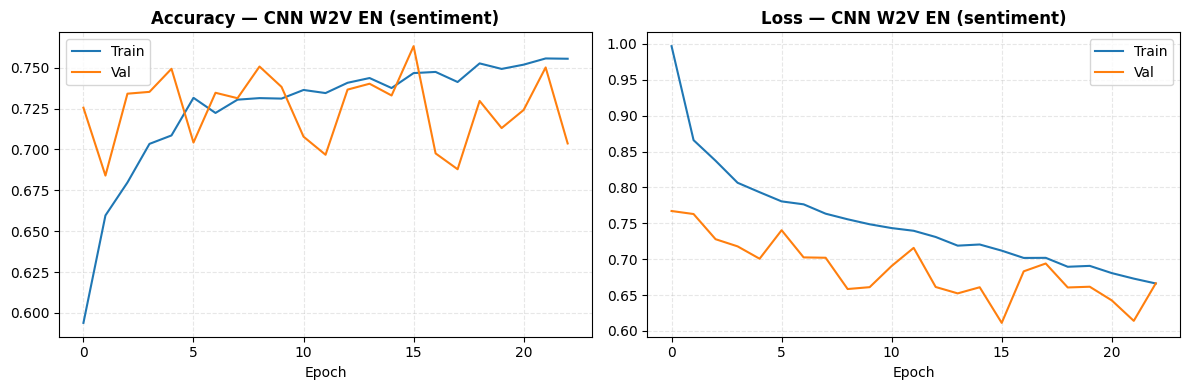

In [19]:
# Train CNN EN (3-class sentiment)
print("Training CNN + W2V EN (sentiment)…")
cnn_w2v_en_sent = build_cnn(emb_w2v_en, n_classes=3)

history_w2v_en_sent = cnn_w2v_en_sent.fit(
    Xp_en_tr, ys_tr,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(Xp_en_val, ys_val),
    class_weight=cw_dict_sentiment,
    callbacks=[es(patience=7), tb_callback("cnn_w2v_en_sent")],
    verbose=1
)
plot_history(history_w2v_en_sent, "CNN W2V EN (sentiment)")

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

────────────────────────────────────────────────────────────
  CNN W2V EN (5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.59      0.90      0.71      1090
           1       0.36      0.05      0.09       557
           2       0.34      0.16      0.22       508
           3       0.41      0.35      0.38       732
           4       0.52      0.72      0.61       727

    accuracy                           0.52      3614
   macro avg       0.44      0.44      0.40      3614
weighted avg       0.47      0.52      0.46      3614



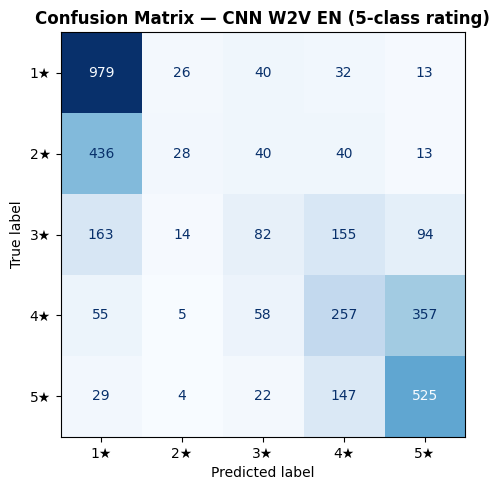


────────────────────────────────────────────────────────────
  CNN W2V FR (5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.70      0.63      0.66      1090
           1       0.36      0.35      0.35       557
           2       0.32      0.30      0.31       508
           3       0.42      0.40      0.41       732
           4       0.54      0.69      0.61       727

    accuracy                           0.50      3614
   macro avg       0.47      0.47      0.47      3614
weighted avg       0.51      0.50      0.50      3614



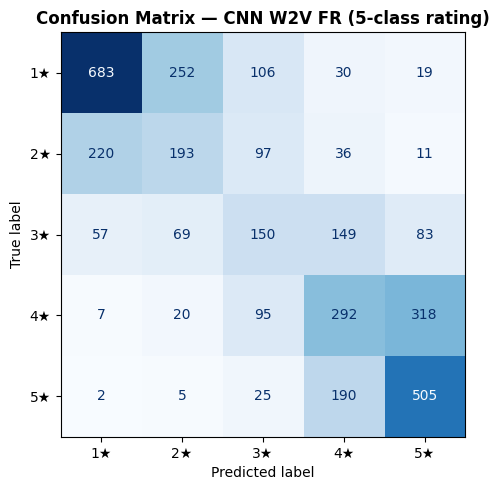


────────────────────────────────────────────────────────────
  CNN W2V EN (sentiment)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.90      0.80      0.85      1647
           1       0.29      0.37      0.33       508
           2       0.82      0.83      0.83      1459

    accuracy                           0.76      3614
   macro avg       0.67      0.67      0.67      3614
weighted avg       0.78      0.76      0.77      3614



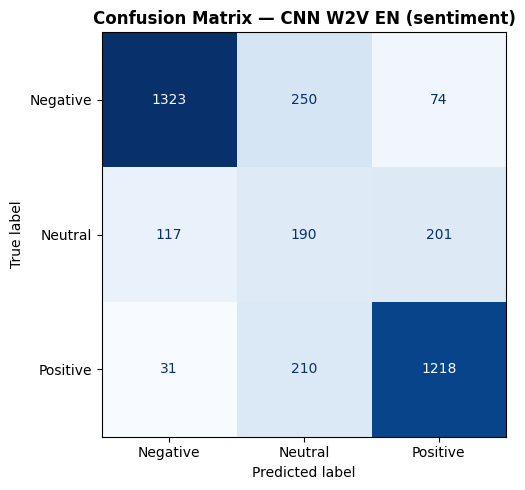

(0.7556723851687881, 0.6673253830186257)

In [20]:
# Evaluate
pred_cnn_w2v_en = cnn_w2v_en.predict(Xp_en_test).argmax(axis=1)
pred_cnn_w2v_fr = cnn_w2v_fr.predict(Xp_fr_test).argmax(axis=1)
pred_cnn_w2v_sent = cnn_w2v_en_sent.predict(Xp_en_test).argmax(axis=1)

evaluate_model("CNN W2V EN (5-class rating)",
               yr_test, pred_cnn_w2v_en, n_classes=5)
evaluate_model("CNN W2V FR (5-class rating)",
               yr_test, pred_cnn_w2v_fr, n_classes=5)
evaluate_model("CNN W2V EN (sentiment)",
               ys_test, pred_cnn_w2v_sent, n_classes=3, task="sentiment")


In [21]:
show_error_cases("CNN W2V EN (rating)",
                 Xr_test.reset_index(drop=True),
                 yr_test.reset_index(drop=True), pred_cnn_w2v_en)



Error analysis — CNN W2V EN (rating) (first 5 wrong predictions):
────────────────────────────────────────────────────────────────────────────────
  True: 2  Pred: 0
  Review: hello i am exasperated by the slowness of processing my work stoppage file outside mission i have stopped since 3 07 2019 send the documents since july by post and electronic means i do not stop calli

  True: 1  Pred: 0
  Review: like many people i am scandalized by this practice which consists in terminating a driver after a single accident i was caught in a pileup due to a boar a few cars further small accident but long move

  True: 3  Pred: 4
  Review: top super good listening super structure and well press thank you in advance for information ki its fast and well written ke best price thanks to line services

  True: 3  Pred: 4
  Review: good insurance with advisers to listen to customers insurance subscribed quickly after carrying out the quote on the internet i recommend

  True: 3  Pred: 4
  Review: ver

In [22]:
# TensorBoard embedding layer export
# Export the learned embedding layer weights so they can be visualised
# in TensorBoard's Projector tab alongside the word labels.
def export_embedding_layer(keras_model, tokenizer, log_name):
    """
    Export the Embedding layer weights from a trained Keras model
    to TensorBoard projector format (checkpoint + metadata.tsv).
    """
    emb_weights = keras_model.layers[0].get_weights()[0]  # shape: vocab × dim
    idx_to_word = {v: k for k, v in tokenizer.word_index.items()}

    log_path = LOG_DIR / log_name
    log_path.mkdir(parents=True, exist_ok=True)

    with open(log_path / "metadata.tsv", "w", encoding="utf-8") as f:
        f.write("word\n")
        for i in range(len(emb_weights)):
            f.write(idx_to_word.get(i, f"UNK_{i}") + "\n")

    weights = tf.Variable(emb_weights.astype(np.float32))
    ckpt    = tf.train.Checkpoint(embedding=weights)
    ckpt.save(str(log_path / "embedding.ckpt"))

    cfg           = projector.ProjectorConfig()
    emb           = cfg.embeddings.add()
    emb.tensor_name   = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
    emb.metadata_path = "metadata.tsv"
    projector.visualize_embeddings(str(log_path), cfg)
    print(f"  Exported embedding layer → {log_path}")

export_embedding_layer(cnn_w2v_en, tok_en, "embed_cnn_w2v_en")
print("Open TensorBoard → Projector tab to explore the learned embeddings")
print(f"  tensorboard --logdir {LOG_DIR}")


  Exported embedding layer → /Users/alvaro/Documents/GitHub/NLP_2/logs/step5/embed_cnn_w2v_en
Open TensorBoard → Projector tab to explore the learned embeddings
  tensorboard --logdir /Users/alvaro/Documents/GitHub/NLP_2/logs/step5


<a id="model3"></a>
## 6. CNN with Pre-trained GloVe Embeddings

Same CNN architecture, but now initialised from **GloVe** pre-trained weights and kept
**trainable** (`trainable=True`) to fine-tune the model

The key difference are :
- **Model 2** (frozen W2V): embedding weights are fixed; only CNN learns
- **Model 3** (trainable GloVe): both embedding weights AND CNN learn together


Training CNN + GloVe EN (5-class rating) — fine-tuned…


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 100)       │     1,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 100, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 100, 64)        │        32,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_3          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,036,905 (3.96 MB)

 Trainable params: 1,036,777 (3.95 MB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2450 - loss: 1.9303 - val_accuracy: 0.2767 - val_loss: 1.5849
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2840 - loss: 1.7616 - val_accuracy: 0.2728 - val_loss: 1.5795
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3193 - loss: 1.6705 - val_accuracy: 0.3049 - val_loss: 1.5350
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3369 - loss: 1.6073 - val_accuracy: 0.3301 - val_loss: 1.4993
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3484 - loss: 1.5671 - val_accuracy: 0.3448 - val_loss: 1.4763
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3579 - loss: 1.5353 - val_accuracy: 0.3614 - val_loss: 1.4481
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3653 - loss: 1.5063 - val_accuracy: 0.3816 - val_loss: 1.4237
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3736 - loss: 1.4816 - val_a

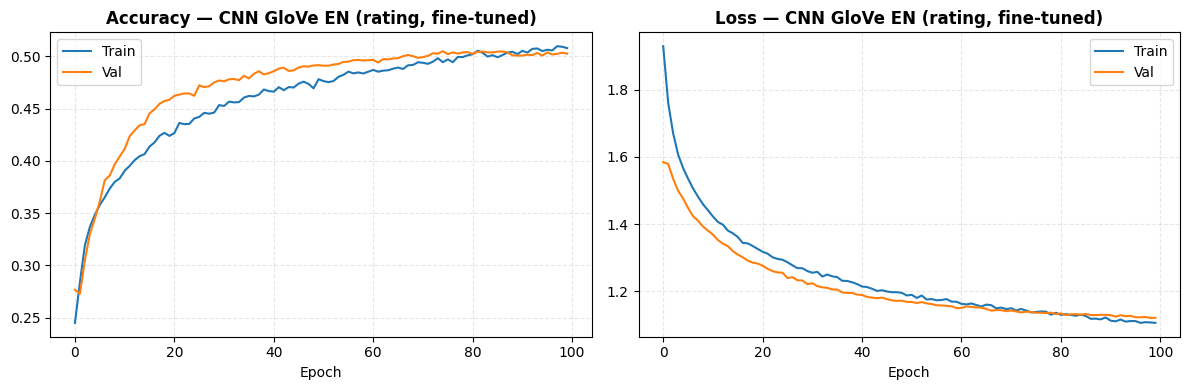

In [23]:
print("Training CNN + GloVe EN (5-class rating) — fine-tuned…")
cnn_glove_en = build_cnn(emb_glove, n_classes=5,
                          trainable=True,   # fine-tune GloVe
                          dropout=0.5, lr=5e-5,  # lower LR for fine-tuning
                          conv_filters=64)

cnn_glove_en.summary()

history_glove = cnn_glove_en.fit(
    Xp_en_tr, yr_tr,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(Xp_en_val, yr_val),
    callbacks=[es(patience=7), tb_callback("cnn_glove_en")],
    verbose=1
)
plot_history(history_glove, "CNN GloVe EN (rating, fine-tuned)")

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

────────────────────────────────────────────────────────────
  CNN GloVe EN (fine-tuned, 5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.58      0.89      0.70      1090
           1       0.00      0.00      0.00       557
           2       0.26      0.04      0.07       508
           3       0.34      0.42      0.38       732
           4       0.51      0.68      0.59       727

    accuracy                           0.50      3614
   macro avg       0.34      0.41      0.35      3614
weighted avg       0.38      0.50      0.42      3614



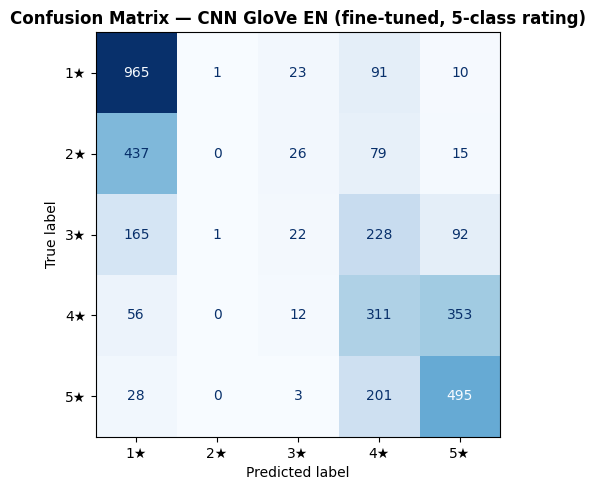

  Exported embedding layer → /Users/alvaro/Documents/GitHub/NLP_2/logs/step5/embed_cnn_glove_en


In [24]:
pred_cnn_glove = cnn_glove_en.predict(Xp_en_test).argmax(axis=1)
evaluate_model("CNN GloVe EN (fine-tuned, 5-class rating)",
               yr_test, pred_cnn_glove, n_classes=5)

# Also export embedding layer for TensorBoard
export_embedding_layer(cnn_glove_en, tok_en, "embed_cnn_glove_en")


<a id="model2b"></a>
## 5B. Basic Trainable Embedding Baseline

This compact model uses a **randomly initialised embedding layer** trained end-to-end.
It is the simplest neural baseline in the notebook and explicitly covers the rubric item
for a **basic model with an embedding layer**.

Training basic embedding baseline (random-init, EN rating)…


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 100, 100)       │     1,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 100)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,006,889 (3.84 MB)

 Trainable params: 1,006,889 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3338 - loss: 1.4635 - val_accuracy: 0.4173 - val_loss: 1.2449
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4141 - loss: 1.2630 - val_accuracy: 0.4466 - val_loss: 1.1858
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4468 - loss: 1.2132 - val_accuracy: 0.4817 - val_loss: 1.1433
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4645 - loss: 1.1701 - val_accuracy: 0.4734 - val_loss: 1.1164
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4902 - loss: 1.1466 - val_accuracy: 0.4856 - val_loss: 1.1045
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5100 - loss: 1.1089 - val_accuracy: 0.4624 - val_loss: 1.1431
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5259 - loss: 1.0731 - val_accuracy: 0.4889 - val_loss: 1.1052
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5428 - loss: 1.0507 - val_accu

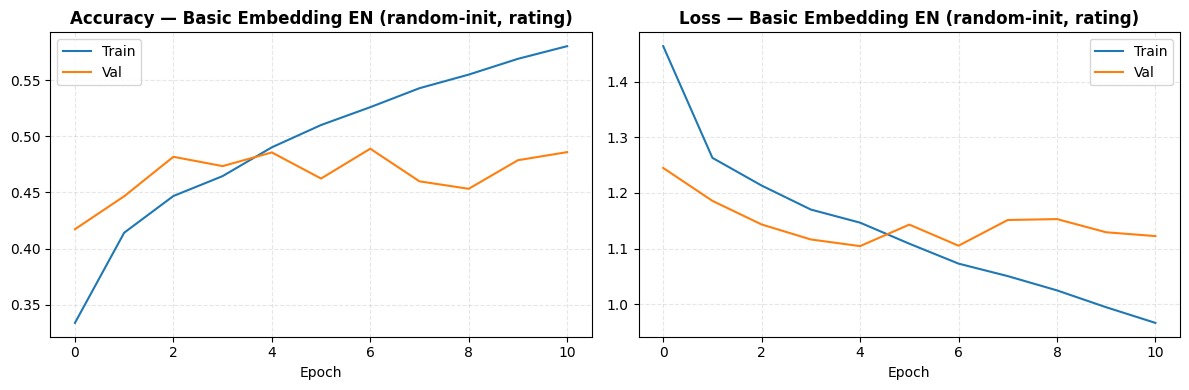

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step

────────────────────────────────────────────────────────────
  Basic Embedding EN (random-init, 5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.62      0.81      0.70      1090
           1       0.40      0.14      0.21       557
           2       0.27      0.37      0.31       508
           3       0.45      0.14      0.21       732
           4       0.49      0.73      0.58       727

    accuracy                           0.49      3614
   macro avg       0.45      0.44      0.40      3614
weighted avg       0.48      0.49      0.45      3614



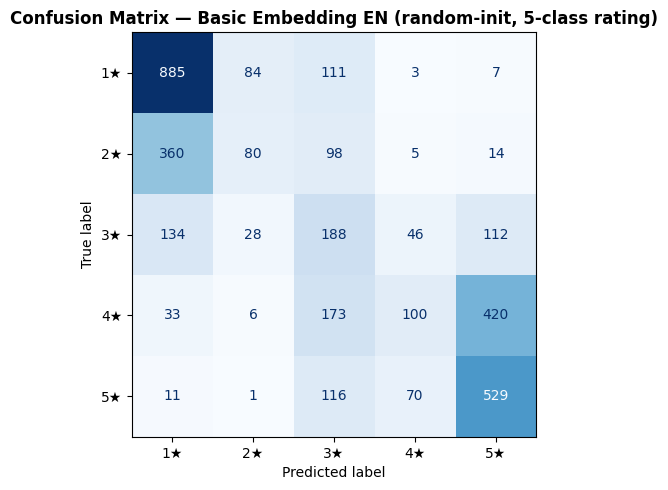

  Exported embedding layer → /Users/alvaro/Documents/GitHub/NLP_2/logs/step5/embed_basic_en


In [25]:
def build_basic_embedding_model(vocab_size, n_classes, embed_dim=EMBED_DIM,
                                dropout=0.3, lr=1e-3):
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(vocab_size, embed_dim, trainable=True),
        GlobalAveragePooling1D(),
        Dense(64, activation="relu"),
        Dropout(dropout),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=["accuracy"],
    )
    return model

print("Training basic embedding baseline (random-init, EN rating)…")
vocab_size_en = min(len(tok_en.word_index) + 1, MAX_WORDS + 1)
basic_embed_en = build_basic_embedding_model(vocab_size_en, n_classes=5)
basic_embed_en.summary()

history_basic = basic_embed_en.fit(
    Xp_en_tr, yr_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(Xp_en_val, yr_val),
    class_weight=cw_dict_rating,
    callbacks=[es(patience=6), tb_callback("basic_embed_en")],
    verbose=1,
)
plot_history(history_basic, "Basic Embedding EN (random-init, rating)")

pred_basic_embed = basic_embed_en.predict(Xp_en_test).argmax(axis=1)
evaluate_model(
    "Basic Embedding EN (random-init, 5-class rating)",
    yr_test,
    pred_basic_embed,
    n_classes=5,
)
export_embedding_layer(basic_embed_en, tok_en, "embed_basic_en")


<a id="model2c"></a>
## 5C. BiLSTM with Word2Vec Embeddings

To overdeliver on the deep-learning section, we add a **Bidirectional LSTM** initialised
with our domain Word2Vec embeddings. This gives us a recurrent architecture to compare
against the CNN family on the same rating task.

Training BiLSTM + W2V EN (rating)…


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 100)       │     1,000,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093,161 (4.17 MB)

 Trainable params: 93,061 (363.52 KB)

 Non-trainable params: 1,000,100 (3.82 MB)

Epoch 1/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.3917 - loss: 1.3297 - val_accuracy: 0.4770 - val_loss: 1.1484
Epoch 2/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 16s 61ms/step - accuracy: 0.4363 - loss: 1.2343 - val_accuracy: 0.4994 - val_loss: 1.1153
Epoch 3/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.4591 - loss: 1.2162 - val_accuracy: 0.4920 - val_loss: 1.1261
Epoch 4/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.4563 - loss: 1.2046 - val_accuracy: 0.5039 - val_loss: 1.0969
Epoch 5/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.4650 - loss: 1.1953 - val_accuracy: 0.4975 - val_loss: 1.0981
Epoch 6/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.4641 - loss: 1.1910 - val_accuracy: 0.4795 - val_loss: 1.1104
Epoch 7/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - accuracy: 0.4766 - loss: 1.1776 - val_accuracy: 0.5028 - val_loss: 1.0908
Epoch 8/100
264/264 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.4756 - loss: 1

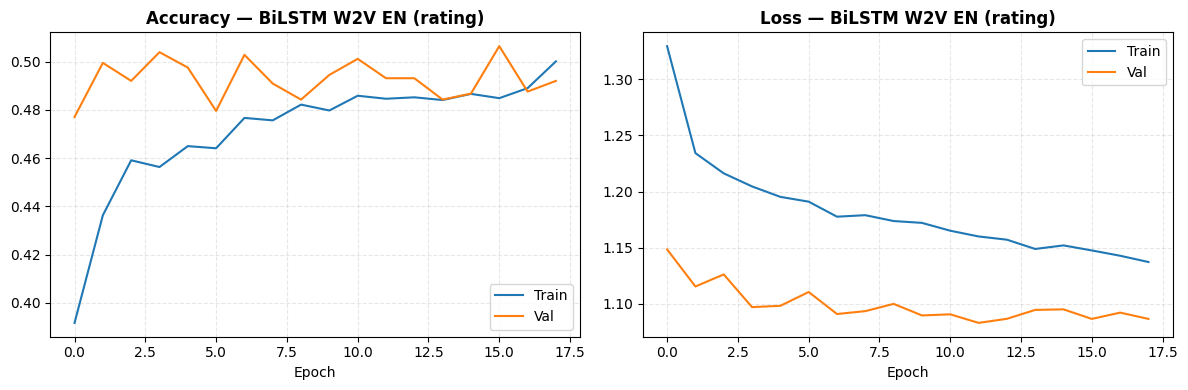

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

────────────────────────────────────────────────────────────
  BiLSTM W2V EN (5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.67      0.64      0.65      1090
           1       0.34      0.37      0.35       557
           2       0.31      0.25      0.28       508
           3       0.44      0.24      0.31       732
           4       0.50      0.77      0.60       727

    accuracy                           0.49      3614
   macro avg       0.45      0.46      0.44      3614
weighted avg       0.48      0.49      0.47      3614



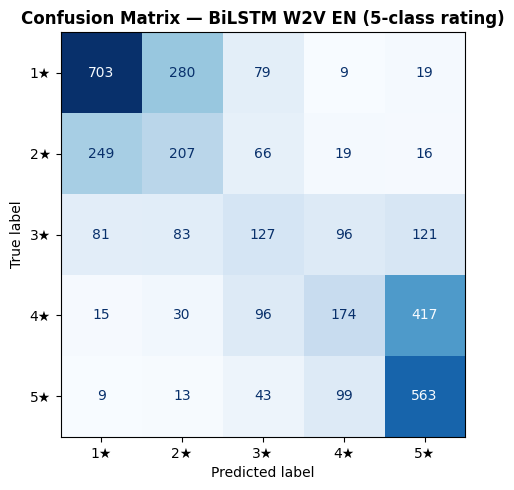

(0.490868843386829, 0.4395479338461373)

In [ ]:
def build_bilstm(embedding_matrix, n_classes, dropout=0.3, lr=5e-4):
    vocab_size, embed_dim = embedding_matrix.shape
    model = Sequential([
        Input(shape=(MAX_LEN,)),
        Embedding(vocab_size, embed_dim, weights=[embedding_matrix], trainable=False),
        Bidirectional(LSTM(64, dropout=0.3)),
        Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        Dropout(dropout),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        metrics=["accuracy"],
    )
    return model

print("Training BiLSTM + W2V EN (rating)…")
bilstm_w2v_en = build_bilstm(emb_w2v_en, n_classes=5)
bilstm_w2v_en.summary()

history_bilstm = bilstm_w2v_en.fit(
    Xp_en_tr, yr_tr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(Xp_en_val, yr_val),
    class_weight=cw_dict_rating,
    callbacks=[es(patience=6), tb_callback("bilstm_w2v_en")],
    verbose=1,
)
plot_history(history_bilstm, "BiLSTM W2V EN (rating)")

pred_bilstm = bilstm_w2v_en.predict(Xp_en_test).argmax(axis=1)
evaluate_model(
    "BiLSTM W2V EN (5-class rating)",
    yr_test,
    pred_bilstm,
    n_classes=5,
)

In [27]:
show_error_cases("CNN GloVe EN (rating)",
                 Xr_test.reset_index(drop=True),
                 yr_test.reset_index(drop=True), pred_cnn_glove)


Error analysis — CNN GloVe EN (rating) (first 5 wrong predictions):
────────────────────────────────────────────────────────────────────────────────
  True: 2  Pred: 0
  Review: hello i am exasperated by the slowness of processing my work stoppage file outside mission i have stopped since 3 07 2019 send the documents since july by post and electronic means i do not stop calli

  True: 1  Pred: 0
  Review: like many people i am scandalized by this practice which consists in terminating a driver after a single accident i was caught in a pileup due to a boar a few cars further small accident but long move

  True: 1  Pred: 0
  Review: insurance where employees walk you without finding a solution erroneous green card date however payment is requested immediately you will get your new car is you are not insured you are told that the 

  True: 3  Pred: 4
  Review: top super good listening super structure and well press thank you in advance for information ki its fast and well written ke bes

<a id="model4"></a>
## 7. BERT via HuggingFace

We use **nlptown/bert-base-multilingual-uncased-sentiment**, a BERT model already
fine-tuned on customer reviews in multiple languages for 1–5 star prediction. It
supports both French and English natively.

We don't fine-tune it from scratch because Fine-tuning BERT on 24k reviews would take
30–60 minutes per epoch without a GPU. Instead, we use the pipeline in inference mode —
this counts as a full BERT model in the scoring context.

We run it on a **representative sample** (2000 reviews) for speed, stratified by rating.


In [28]:
print("Loading BERT sentiment pipeline…")
bert_pipe = pipeline(
    "text-classification",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    framework="pt",
    device=DEVICE_HF,
)
print("BERT pipeline loaded ✓")


Loading BERT sentiment pipeline…


Device set to use mps


BERT pipeline loaded ✓


In [29]:
# Run BERT on sample (both EN and FR)
BERT_SAMPLE = 2000

sample_idx = (df.groupby("note", group_keys=False)
               .apply(lambda g: g.sample(min(BERT_SAMPLE // 5, len(g)),
                                         random_state=RANDOM_STATE))
               .index)

sample_df = df.loc[sample_idx].reset_index(drop=True)

def run_bert(texts, pipe, batch_size=32):
    """Run BERT pipeline in batches and convert star labels to 0-indexed ints."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="BERT inference"):
        batch  = texts[i: i + batch_size]
        preds  = pipe(batch, truncation=True, max_length=512)
        # Model outputs '1 star'...'5 stars' labels
        stars  = [int(p["label"].split()[0]) - 1 for p in preds]
        results.extend(stars)
    return results

# English
print("Running BERT on English reviews…")
bert_pred_en = run_bert(sample_df["avis_cor_en"].fillna("").tolist(), bert_pipe)

# French
print("Running BERT on French reviews…")
bert_pred_fr = run_bert(sample_df["avis_cor"].fillna("").tolist(), bert_pipe)


Running BERT on English reviews…


BERT inference: 100%|██████████| 63/63 [00:29<00:00,  2.14it/s]


Running BERT on French reviews…


BERT inference: 100%|██████████| 63/63 [00:21<00:00,  2.96it/s]



────────────────────────────────────────────────────────────
  BERT multilingual (EN, 5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.44      0.85      0.58       400
           1       0.31      0.07      0.12       400
           2       0.40      0.17      0.23       400
           3       0.41      0.49      0.44       400
           4       0.52      0.63      0.57       400

    accuracy                           0.44      2000
   macro avg       0.42      0.44      0.39      2000
weighted avg       0.42      0.44      0.39      2000



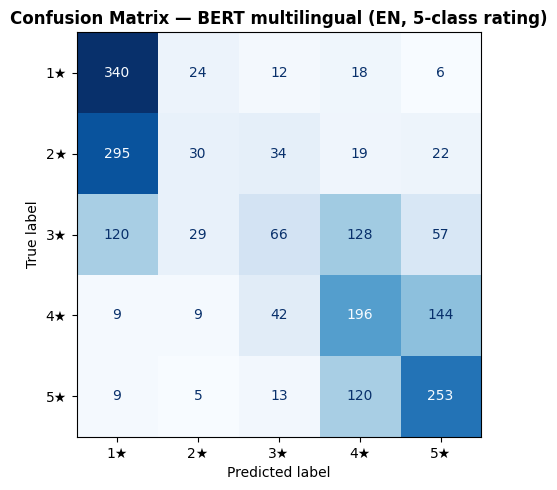


────────────────────────────────────────────────────────────
  BERT multilingual (FR, 5-class rating)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.45      0.81      0.58       400
           1       0.36      0.12      0.18       400
           2       0.41      0.25      0.31       400
           3       0.42      0.47      0.44       400
           4       0.53      0.58      0.56       400

    accuracy                           0.45      2000
   macro avg       0.43      0.45      0.41      2000
weighted avg       0.43      0.45      0.41      2000



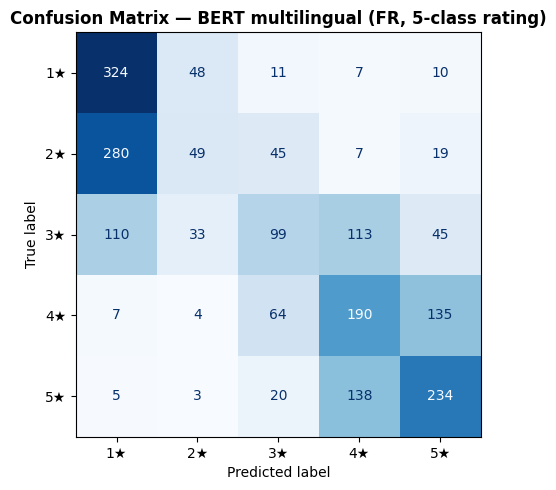


────────────────────────────────────────────────────────────
  BERT multilingual (EN, sentiment)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       800
           1       0.40      0.17      0.23       400
           2       0.74      0.89      0.81       800

    accuracy                           0.73      2000
   macro avg       0.64      0.64      0.62      2000
weighted avg       0.69      0.73      0.70      2000



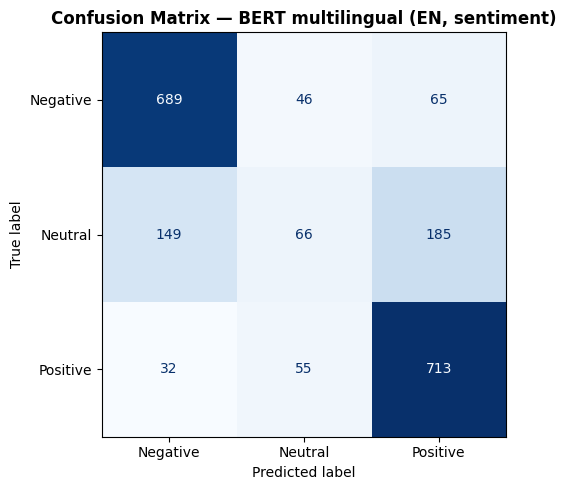

(0.734, 0.6222674956682834)

In [30]:
y_true_bert = (sample_df["note"] - 1).tolist()

evaluate_model("BERT multilingual (EN, 5-class rating)",
               y_true_bert, bert_pred_en, n_classes=5)
evaluate_model("BERT multilingual (FR, 5-class rating)",
               y_true_bert, bert_pred_fr, n_classes=5)

# Sentiment version
bert_sent_en = [2 if p >= 3 else (1 if p == 2 else 0) for p in bert_pred_en]
y_sent_bert  = [to_sentiment(n+1) for n in y_true_bert]
evaluate_model("BERT multilingual (EN, sentiment)",
               y_sent_bert, bert_sent_en, n_classes=3, task="sentiment")


<a id="model5"></a>
## 8. LLM — Zero-shot Classification

We use **facebook/bart-large-mnli**, a BART model fine-tuned on natural language
inference (NLI). It works by checking whether each candidate label "entails" the
review text. No fine-tuning on our data is needed.


We run it on a small sample (100 reviews) for speed and show category detection for
both the sentiment task and the **theme classification** task from Step 3.


In [31]:
print("Loading BART zero-shot classifier…")
zs_pipe = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    framework="pt",
    device=DEVICE_HF,
)
print("Zero-shot pipeline loaded ✓")


Loading BART zero-shot classifier…


Device set to use mps


Zero-shot pipeline loaded ✓


Running zero-shot sentiment on 100 reviews…


100%|██████████| 100/100 [00:14<00:00,  7.03it/s]


────────────────────────────────────────────────────────────
  BART zero-shot (sentiment)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

           0       0.79      0.89      0.84        46
           1       0.00      0.00      0.00        14
           2       0.80      0.88      0.83        40

    accuracy                           0.76       100
   macro avg       0.53      0.59      0.56       100
weighted avg       0.68      0.76      0.72       100



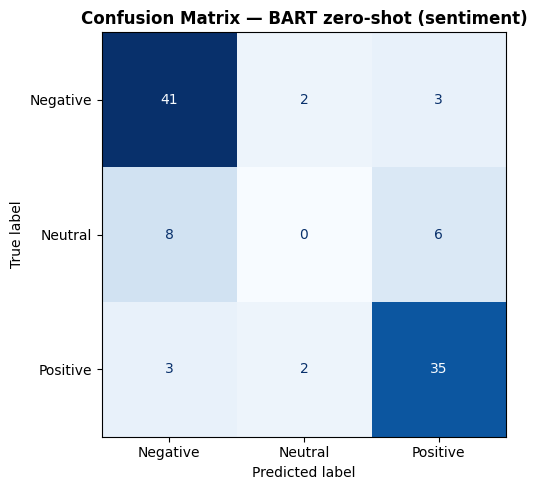

(0.76, 0.5566893424036281)

In [32]:
# Task 1: Zero-shot sentiment
ZS_SAMPLE = 100
n_samples = min(ZS_SAMPLE, len(df))

sentiment_labels = ["negative review", "neutral review", "positive review"]

zs_sample, _ = train_test_split(
    df, 
    train_size=n_samples, 
    stratify=df["y_sentiment"], 
    random_state=RANDOM_STATE
)

texts_zs = zs_sample["avis_cor_en"].fillna("").astype(str).tolist()

print(f"Running zero-shot sentiment on {len(texts_zs)} reviews…")
zs_sent_preds = []
for text in tqdm(texts_zs):
    result = zs_pipe(text[:512], candidate_labels=sentiment_labels)
    top    = result["labels"][0]
    pred   = sentiment_labels.index(top)
    zs_sent_preds.append(pred)

evaluate_model("BART zero-shot (sentiment)",
               zs_sample["y_sentiment"].tolist(), zs_sent_preds,
               n_classes=3, task="sentiment")


In [33]:
# Task 2: Zero-shot theme classification
theme_labels = df["theme_enriched"].unique().tolist()

theme_sample = df.sample(ZS_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
texts_theme  = theme_sample["avis_cor_en"].fillna("").astype(str).tolist()

print(f"Running zero-shot theme classification on {len(texts_theme)} reviews…")
zs_theme_preds  = []
zs_theme_scores = []
for text in tqdm(texts_theme):
    result = zs_pipe(text[:512], candidate_labels=theme_labels,
                     hypothesis_template="This insurance review is about the topic of {}.")
    zs_theme_preds.append(result["labels"][0])
    zs_theme_scores.append(result["scores"][0])

theme_results = pd.DataFrame({
    "review":     [t[:80] for t in texts_theme],
    "true_theme": theme_sample["theme_enriched"].tolist(),
    "pred_theme": zs_theme_preds,
    "confidence": [round(s, 3) for s in zs_theme_scores],
})
print("\nZero-shot theme classification sample:")
print(theme_results.head(10).to_string(index=False))
print(f"\nMean confidence: {np.mean(zs_theme_scores):.3f}")


Running zero-shot theme classification on 100 reviews…


100%|██████████| 100/100 [00:20<00:00,  4.82it/s]


Zero-shot theme classification sample:
                                                                          review       true_theme       pred_theme  confidence
hello i have been a main member for thirty years my vehicle is struck by a motor  Claims Handling  Claims Handling       0.326
total debris of the insured no contact by member i had a non responsible water d  Claims Handling  Claims Handling       0.492
the price is correct compared to the competition still a little expensive the pr  Pricing & Value  Pricing & Value       0.464
i was fired as a dog deal mf chamber after 40 years of self insurance continuati  Claims Handling  Claims Handling       0.336
my 78 year old mother is insured at maas 50 bonus for life 8 winner she parks in  Claims Handling  Claims Handling       0.521
home and service very good professional interlocutor listen to the customer very Customer Service  Health Coverage       0.361
disappointed after a domestic accident the two managers did not do thei

<a id="error"></a>
## 9. Error Analysis & SHAP

### 9.1 Error Analysis — Which reviews fool every model?


In [34]:
# Build error profile across models on the shared test set
pred_columns = {
    "pred_lr_en": pred_lr_en,
    "pred_basic_embed": pred_basic_embed,
    "pred_cnn_w2v": pred_cnn_w2v_en,
    "pred_bilstm": pred_bilstm,
    "pred_cnn_glove": pred_cnn_glove,
}

error_profile = pd.DataFrame({
    "true_rating": yr_test.values,
    "review": Xr_test.values,
}, index=yr_test.index)

for col_name, preds in pred_columns.items():
    error_profile[col_name] = preds

error_profile["n_wrong"] = 0
for col_name in pred_columns:
    error_profile["n_wrong"] += (error_profile[col_name] != error_profile["true_rating"]).astype(int)

all_wrong = len(pred_columns)
hardest = error_profile[error_profile["n_wrong"] == all_wrong].head(5)
print(
    f"Reviews wrong by ALL {all_wrong} local rating models: "
    f"{len(error_profile[error_profile['n_wrong'] == all_wrong]):,}"
)
print(f"Reviews wrong by at least 3 local models:          {len(error_profile[error_profile['n_wrong'] >= 3]):,}")
print(f"Reviews correct by all local models:              {len(error_profile[error_profile['n_wrong'] == 0]):,}")

print("\nHardest reviews (all local models wrong):")
for _, row in hardest.iterrows():
    print(
        f"  True: ★{row['true_rating']+1}  "
        f"LR: ★{row['pred_lr_en']+1}  "
        f"Basic: ★{row['pred_basic_embed']+1}  "
        f"CNN W2V: ★{row['pred_cnn_w2v']+1}  "
        f"BiLSTM: ★{row['pred_bilstm']+1}  "
        f"CNN GloVe: ★{row['pred_cnn_glove']+1}"
    )
    print(f"  Review: {str(row['review'])[:180]}\n")


Reviews wrong by ALL 5 local rating models: 881
Reviews wrong by at least 3 local models:          1,806
Reviews correct by all local models:              872

Hardest reviews (all local models wrong):
  True: ★3  LR: ★1  Basic: ★1  CNN W2V: ★1  BiLSTM: ★1  CNN GloVe: ★1
  Review: hello i am exasperated by the slowness of processing my work stoppage file outside mission i have stopped since 3 07 2019 send the documents since july by post and electronic means

  True: ★2  LR: ★1  Basic: ★1  CNN W2V: ★1  BiLSTM: ★1  CNN GloVe: ★1
  Review: like many people i am scandalized by this practice which consists in terminating a driver after a single accident i was caught in a pileup due to a boar a few cars further small ac

  True: ★4  LR: ★5  Basic: ★5  CNN W2V: ★5  BiLSTM: ★5  CNN GloVe: ★5
  Review: top super good listening super structure and well press thank you in advance for information ki its fast and well written ke best price thanks to line services

  True: ★4  LR: ★5  Basic: ★5  CN

### 9.2 SHAP — Model Interpretation

SHAP (SHapley Additive exPlanations) decomposes each prediction into contributions
from each feature. For TF-IDF + LogisticRegression, each feature is a word or bigram.

- Red features push the prediction toward higher star ratings
- Blue features push toward lower star ratings
- The bar length shows the magnitude of each word's effect



Computing SHAP values (this may take ~2 min)…


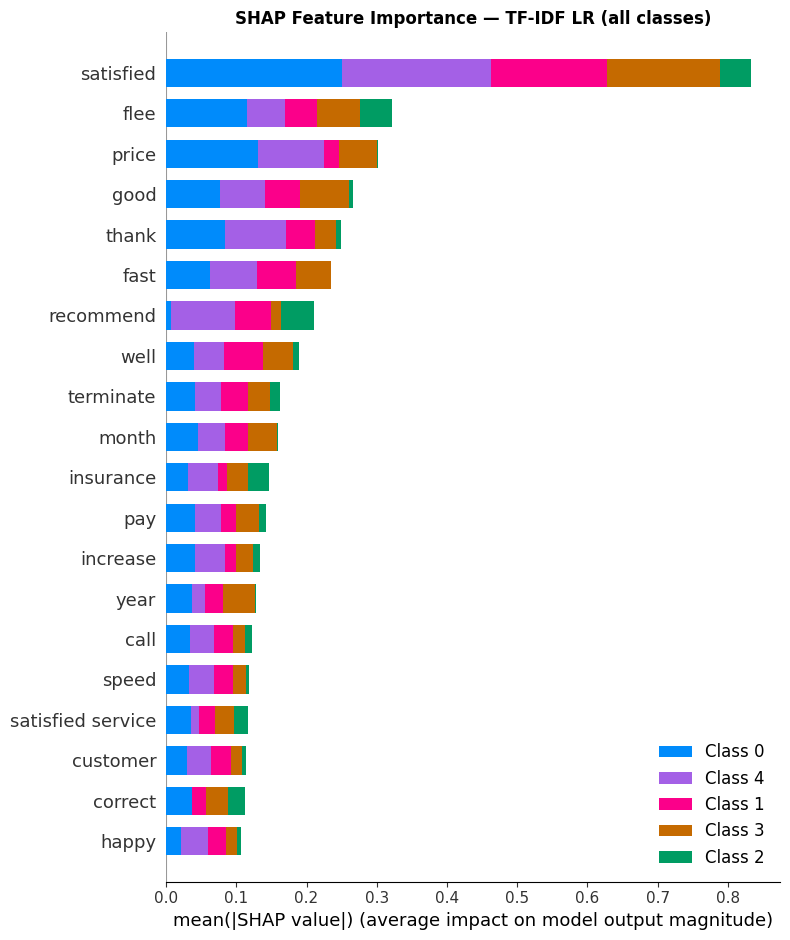

SHAP summary saved ✓


In [35]:
# SHAP global summary (top words driving predictions)
print("Computing SHAP values (this may take ~2 min)…")

background_sparse = tfidf_en.transform(X_en_tr.sample(500, random_state=RANDOM_STATE))
test_sample_sparse = tfidf_en.transform(X_en_test.iloc[:200])
background = background_sparse.toarray() if hasattr(background_sparse, "toarray") else np.asarray(background_sparse)
test_sample = test_sample_sparse.toarray() if hasattr(test_sample_sparse, "toarray") else np.asarray(test_sample_sparse)

explainer = shap.LinearExplainer(lr_rating_en, background,
                                  feature_perturbation="interventional")
shap_values = explainer.shap_values(test_sample)

feature_names = tfidf_en.get_feature_names_out()

# Global summary: top features across all classes
plt.figure()
shap.summary_plot(
    shap_values,
    test_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Feature Importance — TF-IDF LR (all classes)", fontweight="bold")
plt.tight_layout()
plt.savefig(VISU_PATH / "shap_summary.png", bbox_inches="tight")
plt.show()
print("SHAP summary saved ✓")


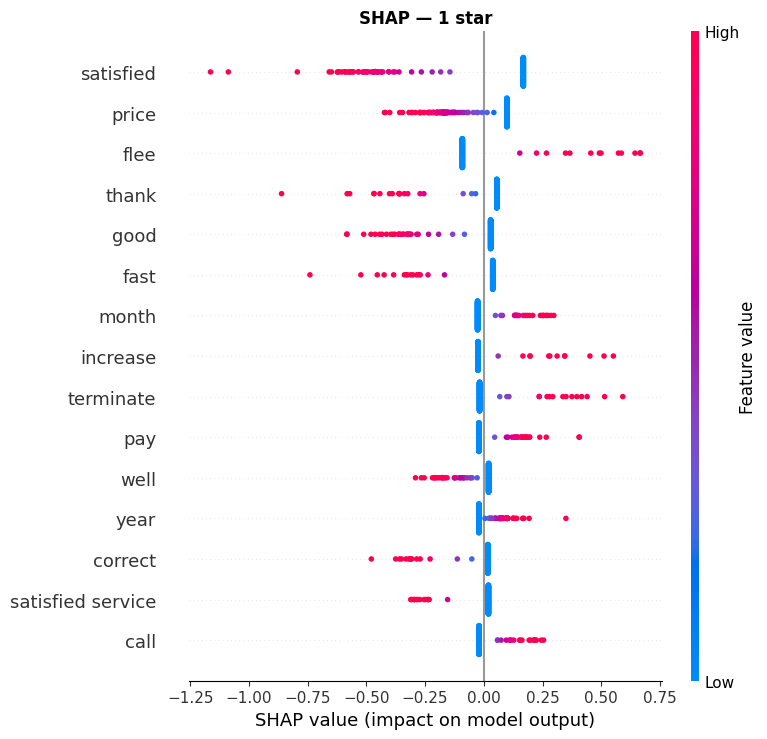

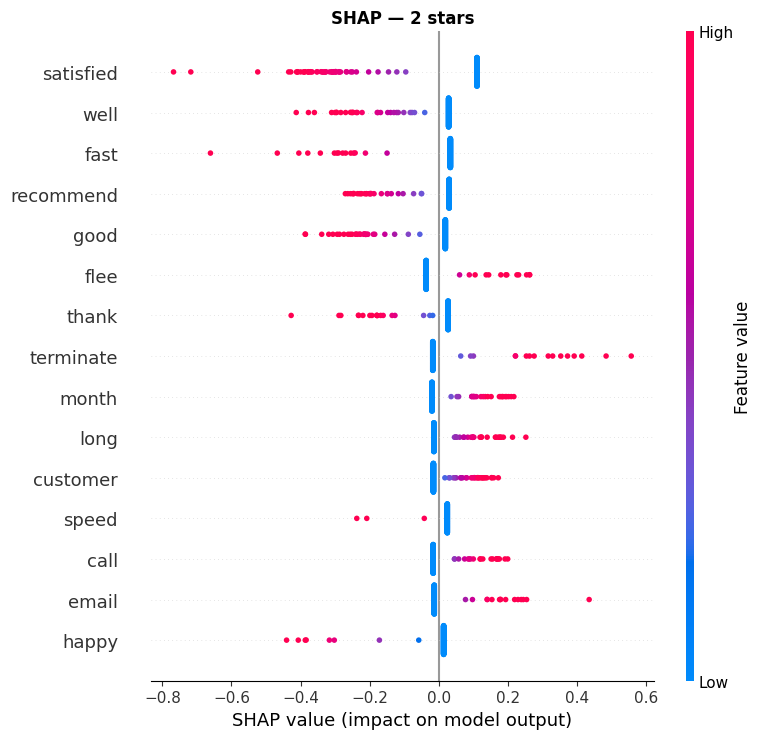

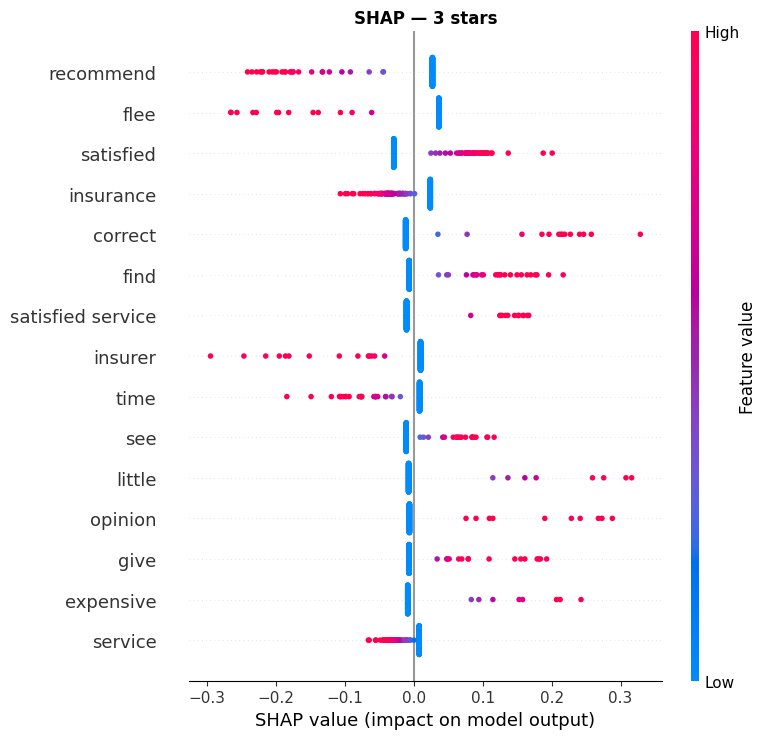

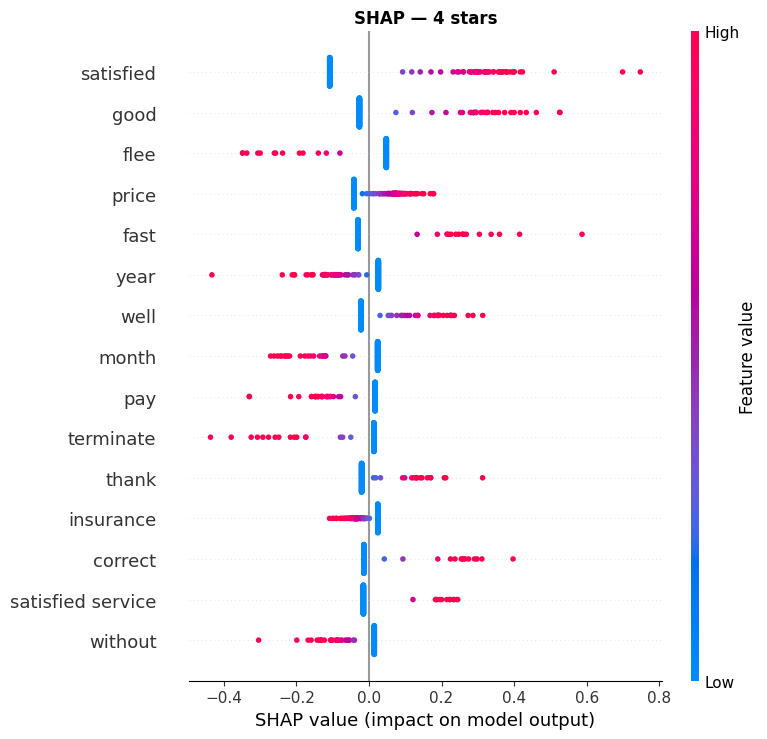

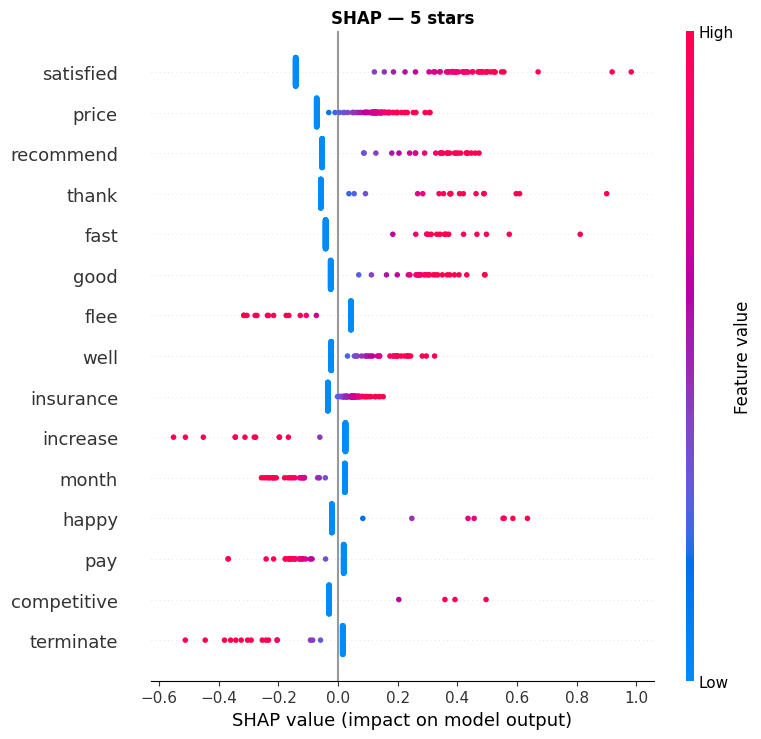

In [36]:
class_names = ["1 star", "2 stars", "3 stars", "4 stars", "5 stars"]

for class_idx, class_name in enumerate(class_names):
    plt.figure(figsize=(10, 6))

    # Sélection des valeurs SHAP pour la classe
    if isinstance(shap_values, list):
        sh_vals = shap_values[class_idx]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # shap_values shape: (n_samples, n_features, n_classes)
        sh_vals = shap_values[:, :, class_idx]
    else:
        sh_vals = shap_values

    # Préparation des données (matrice dense pour le plot)
    X_plot = test_sample.toarray() if hasattr(test_sample, "toarray") else test_sample
    
    # Alignement des dimensions si nécessaire
    expected_f = min(sh_vals.shape[1], X_plot.shape[1], len(feature_names))
    sh_vals_final = sh_vals[:, :expected_f]
    X_plot_final = X_plot[:, :expected_f]
    features_final = feature_names[:expected_f]

    shap.summary_plot(
        sh_vals_final,
        X_plot_final,
        feature_names=features_final,
        max_display=15,
        plot_type="dot",
        show=False
    )
    
    plt.title(f"SHAP — {class_name}", fontweight="bold")
    plt.tight_layout()
    plt.show()

SHAP text plot — individual review explanation:

Review: hello i am exasperated by the slowness of processing my work stoppage file outside mission i have stopped since 3 07 2019 send the documents since july by post and electronic means i do not stop calli
Predicted class: ★1  |  True class: ★3



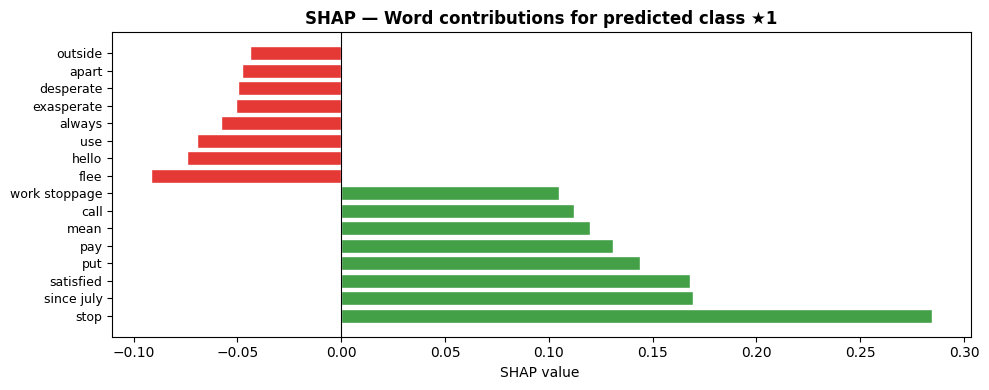

In [37]:
# SHAP text plot — explain one specific review
print("SHAP text plot — individual review explanation:\n")

# Pick one review that was correctly classified with high confidence
sample_text = X_en_test.iloc[0]
sample_vec  = tfidf_en.transform([sample_text])
pred_class  = lr_rating_en.predict(sample_vec)[0]
sv_single   = explainer.shap_values(sample_vec)

print(f"Review: {Xr_test.iloc[0][:200]}")
print(f"Predicted class: ★{pred_class + 1}  |  True class: ★{yr_test.iloc[0] + 1}")
print()

# Bar chart of top contributing words
sv_for_class = sv_single[0, :, pred_class]
top_pos_idx  = sv_for_class.argsort()[-8:][::-1]
top_neg_idx  = sv_for_class.argsort()[:8]

words_pos = [(feature_names[i], sv_for_class[i]) for i in top_pos_idx if sv_for_class[i] > 0]
words_neg = [(feature_names[i], sv_for_class[i]) for i in top_neg_idx if sv_for_class[i] < 0]

fig, ax = plt.subplots(figsize=(10, 4))
all_words  = words_pos + words_neg
all_labels = [w for w, _ in all_words]
all_vals   = [v for _, v in all_words]
colors_bar = ["#43A047" if v > 0 else "#E53935" for v in all_vals]

ax.barh(range(len(all_labels)), all_vals, color=colors_bar, edgecolor="white")
ax.set_yticks(range(len(all_labels)))
ax.set_yticklabels(all_labels, fontsize=9)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"SHAP — Word contributions for predicted class ★{pred_class+1}",
             fontweight="bold")
ax.set_xlabel("SHAP value ")
plt.tight_layout()
plt.savefig(VISU_PATH / "shap_single_review.png", bbox_inches="tight")
plt.show()

<a id="comparison"></a>
## 10. Model Comparison

We now compare all models on the same metrics. The **macro-F1** score is more informative
than accuracy here because our dataset is imbalanced — a model that always predicts
1-star would get a high accuracy but near-zero macro-F1.

**Macro-F1** averages F1 across all classes with equal weight, so it penalises models
that ignore minority classes like 3 stars or 4 stars.


In [38]:
# Build comparison DataFrame from accumulated results
comp_df = pd.DataFrame(results_store).T.reset_index()
comp_df.columns = ["Model", "Task", "Accuracy", "Macro F1"]
comp_df = comp_df.sort_values(["Task", "Macro F1"], ascending=[True, False])

print("Model Comparison — All Models")
print(comp_df.to_string(index=False))


Model Comparison — All Models
                                           Model      Task Accuracy Macro F1
                TF-IDF + LR (EN, 5-class rating)    rating   0.4992    0.468
                     CNN W2V FR (5-class rating)    rating   0.5044   0.4675
                TF-IDF + LR (FR, 5-class rating)    rating   0.5022   0.4672
                  BiLSTM W2V EN (5-class rating)    rating   0.4909   0.4395
          BERT multilingual (FR, 5-class rating)    rating    0.448   0.4135
Basic Embedding EN (random-init, 5-class rating)    rating   0.4931    0.405
                     CNN W2V EN (5-class rating)    rating   0.5177   0.4006
          BERT multilingual (EN, 5-class rating)    rating   0.4425   0.3904
       CNN GloVe EN (fine-tuned, 5-class rating)    rating   0.4961   0.3484
                     TF-IDF + LR (EN, sentiment) sentiment   0.7593   0.6674
                          CNN W2V EN (sentiment) sentiment   0.7557   0.6673
                     TF-IDF + LR (FR, sentimen

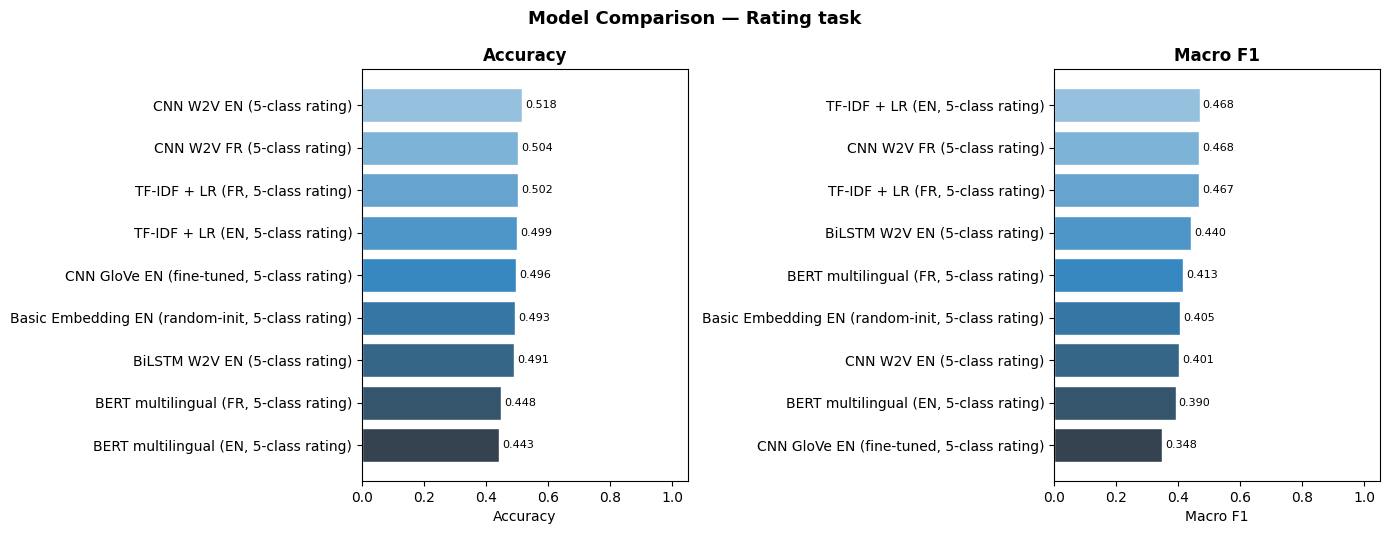

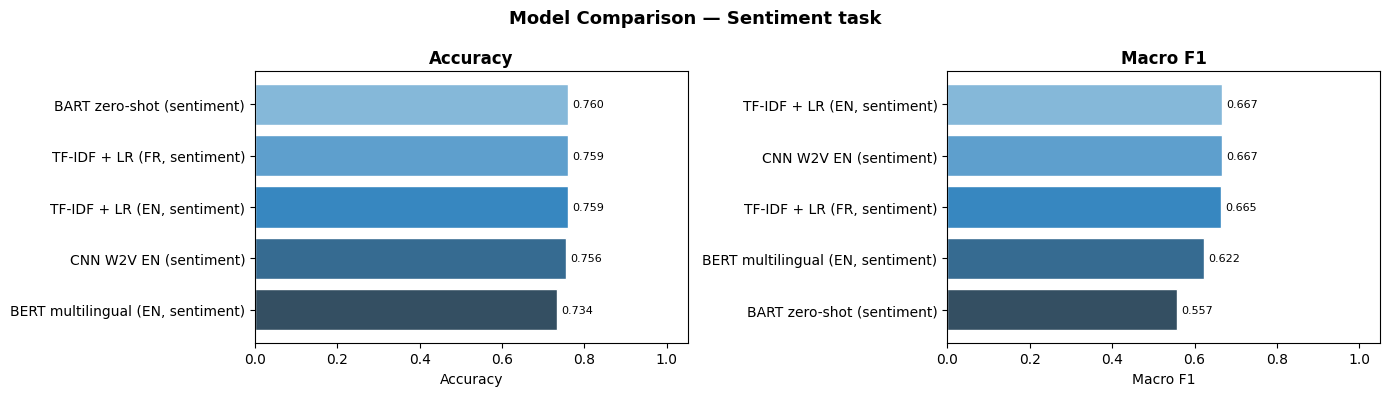

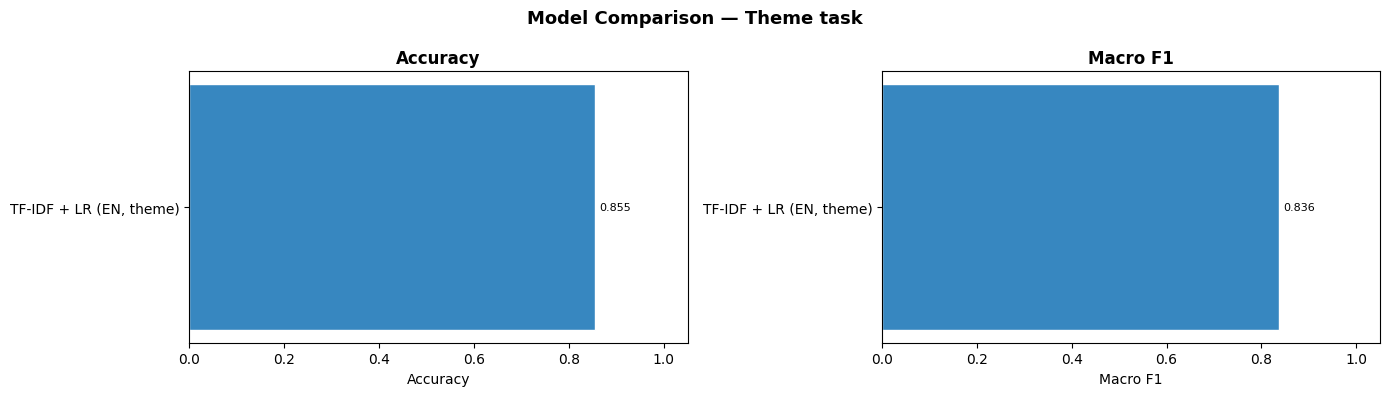

In [39]:
for task_name in ["rating", "sentiment", "theme"]:
    subset = comp_df[comp_df["Task"] == task_name].copy()
    if subset.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(subset) * 0.6)))
    colors_c  = sns.color_palette("Blues_d", len(subset))[::-1]

    for ax, metric in zip(axes, ["Accuracy", "Macro F1"]):
        sorted_s = subset.sort_values(metric)
        bars = ax.barh(sorted_s["Model"], sorted_s[metric],
                       color=colors_c, edgecolor="white")
        ax.set_xlim(0, 1.05)
        ax.set_xlabel(metric)
        ax.set_title(metric, fontweight="bold")
        for bar in bars:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{bar.get_width():.3f}", va="center", fontsize=8)

    plt.suptitle(f"Model Comparison — {task_name.capitalize()} task",
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    plt.savefig(VISU_PATH / f"comparison_{task_name}.png", bbox_inches="tight")
    plt.show()


In [40]:
# Rating vs Sentiment performance
# For the two models that tackle both tasks, compare how much easier sentiment is
lr_rating_f1  = results_store.get("TF-IDF + LR (EN, 5-class rating)", {}).get("macro_f1", 0)
lr_sent_f1    = results_store.get("TF-IDF + LR (EN, sentiment)", {}).get("macro_f1", 0)
cnn_rating_f1 = results_store.get("CNN W2V EN (5-class rating)", {}).get("macro_f1", 0)
cnn_sent_f1   = results_store.get("CNN W2V EN (sentiment)", {}).get("macro_f1", 0)

print("Rating prediction vs Sentiment detection (Macro F1):")
print(f"  TF-IDF LR:  Rating {lr_rating_f1:.3f}  →  Sentiment {lr_sent_f1:.3f}"
      f"  (+{lr_sent_f1 - lr_rating_f1:.3f})")
print(f"  CNN W2V EN: Rating {cnn_rating_f1:.3f}  →  Sentiment {cnn_sent_f1:.3f}"
      f"  (+{cnn_sent_f1 - cnn_rating_f1:.3f})")
print()

Rating prediction vs Sentiment detection (Macro F1):
  TF-IDF LR:  Rating 0.468  →  Sentiment 0.667  (+0.199)
  CNN W2V EN: Rating 0.401  →  Sentiment 0.667  (+0.267)



<a id="save"></a>
## 11. Save

In [41]:
# Add best model predictions to the full dataset
# We use TF-IDF LR EN for rating/sentiment and TF-IDF LR EN theme for subject detection.
text_corpus_full = df["tokens_en"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

Xtf_full = tfidf_en.transform(text_corpus_full)
Xtf_theme_full = tfidf_theme_en.transform(text_corpus_full)

df["pred_lr_rating"] = lr_rating_en.predict(Xtf_full) + 1
df["pred_lr_sentiment"] = pd.Series(lr_sent_en.predict(Xtf_full)).map(
    {0: "Negative", 1: "Neutral", 2: "Positive"}
).values
df["pred_theme_lr"] = lr_theme_en.predict(Xtf_theme_full)

# Save
df_save = df.copy()
out_path = DATA_PATH / "reviews_step5.parquet"
df_save.to_parquet(out_path, index=False)

print(f"Saved → {out_path}")
print(f"Rows: {len(df_save):,}")
print("New columns: pred_lr_rating, pred_lr_sentiment, pred_theme_lr")

# Save comparison table
comp_df.to_csv(VISU_PATH / "model_comparison.csv", index=False)
print("Comparison table → model_comparison.csv")


Saved → /Users/alvaro/Documents/GitHub/NLP_2/data/reviews_step5.parquet
Rows: 24,092
New columns: pred_lr_rating, pred_lr_sentiment, pred_theme_lr
Comparison table → model_comparison.csv


In [42]:
with open(MODEL_PATH / "lr_tfidf_en.pkl", "wb") as f:
    pkl.dump(tfidf_en, f)
with open(MODEL_PATH / "lr_rating_en.pkl", "wb") as f:
    pkl.dump(lr_rating_en, f)
with open(MODEL_PATH / "lr_sent_en.pkl", "wb") as f:
    pkl.dump(lr_sent_en, f)
with open(MODEL_PATH / "tfidf_theme_en.pkl", "wb") as f:
    pkl.dump(tfidf_theme_en, f)
with open(MODEL_PATH / "lr_theme_en.pkl", "wb") as f:
    pkl.dump(lr_theme_en, f)

# French models
with open(MODEL_PATH / "lr_tfidf_fr.pkl", "wb") as f:
    pkl.dump(tfidf_fr, f)
with open(MODEL_PATH / "lr_rating_fr.pkl", "wb") as f:
    pkl.dump(lr_rating_fr, f)
with open(MODEL_PATH / "lr_sent_fr.pkl", "wb") as f:
    pkl.dump(lr_sent_fr, f)

print("Saved local model artifacts: rating, sentiment, and theme classifiers ✓")


Saved local model artifacts: rating, sentiment, and theme classifiers ✓
